<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Artificial Intelligence and Machine Learning</center></font>
<center><font size=6>Model Deployment - Project Solution</center></font>

<center><p float="center">
  <img src="https://i.ibb.co/hxfpLcn9/superkart.webp" width="720"/>
</p></center>

<center><font size=6>SuperKart</center></font>

## Note: This is a sample solution for the project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.

# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [1]:
#Installing the libraries with the specified versions

!pip install pandas==2.2.2 numpy==2.0.2 scikit-learn==1.6.1 xgboost==2.1.4 joblib==1.4.2 streamlit==1.43.2 PyGithub==2.6.1 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.5 MB/s eta 0:00:00


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for pushing deployment files to GitHub
from github import Github

# **Loading the dataset**

In [3]:
# Uncomment the below snippet of code if the drive needs to be mounted
#from google.colab import drive
#drive.mount('/content/drive')

In [4]:
kart = pd.read_csv("SuperKart.csv")

In [5]:
# copying data to another variable to avoid any changes to original data
data = kart.copy()

# **Data Overview**

## View the first and last 5 rows of the dataset

In [6]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [7]:
data.tail()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08


## Understand the shape of the dataset

In [8]:
print(f"There are {data.shape[0]} rows and {data.shape[1]} columns.")

There are 8763 rows and 12 columns.


## Check the data types of the columns for the dataset

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


* Product_Weight, Product_Allocated_Area, Product_MRP, Store_Establishment_Year, Product_Store_Sales_Total are the numeric columns while the rest are object ones.     

## Statistical summary of the data

**Let's check the statistical summary of the data.**

In [10]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,8763,8763,FD306,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,8763.0,NaN,NaN,NaN,12.653792,2.21732,4.0,11.15,12.66,14.18,22.0
Product_Sugar_Content,8763,4,Low Sugar,4885,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,8763.0,NaN,NaN,NaN,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_Type,8763,16,Fruits and Vegetables,1249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,8763.0,NaN,NaN,NaN,147.032539,30.69411,31.0,126.16,146.74,167.585,266.0
Store_Id,8763,4,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,8763.0,NaN,NaN,NaN,2002.032751,8.388381,1987.0,1998.0,2009.0,2009.0,2009.0
Store_Size,8763,3,Medium,6025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,8763,3,Tier 2,6262,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations**
- There are 16 different product types and fruits and vegetables have been sold the highest number of times (1249).
- There are 4 unique stores in the dataset.
- The revenue generated from the sale of a particular product at a certain outlet varies from 33 to 8000 with 50% of the values lying above 2762.

## Checking for duplicate values

In [11]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

* There are no duplicate values in the data.

## Checking for missing values

In [12]:
# checking for missing values in the data
data.isnull().sum()

,0
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


* There are no missing values in the data

# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

In [13]:
# function to plot a boxplot and a histogram along the same scale.

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

### **Product_Weight**

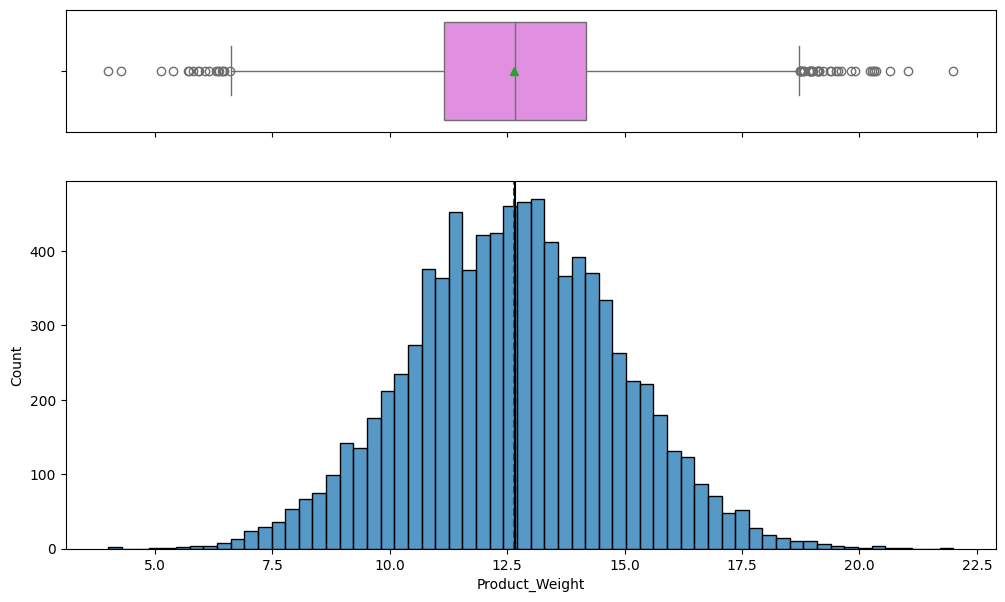

In [14]:
histogram_boxplot(data, "Product_Weight")

- The product weight is normally distributed with mean and median lying around 12.5.

### **Product_Allocated_Area**

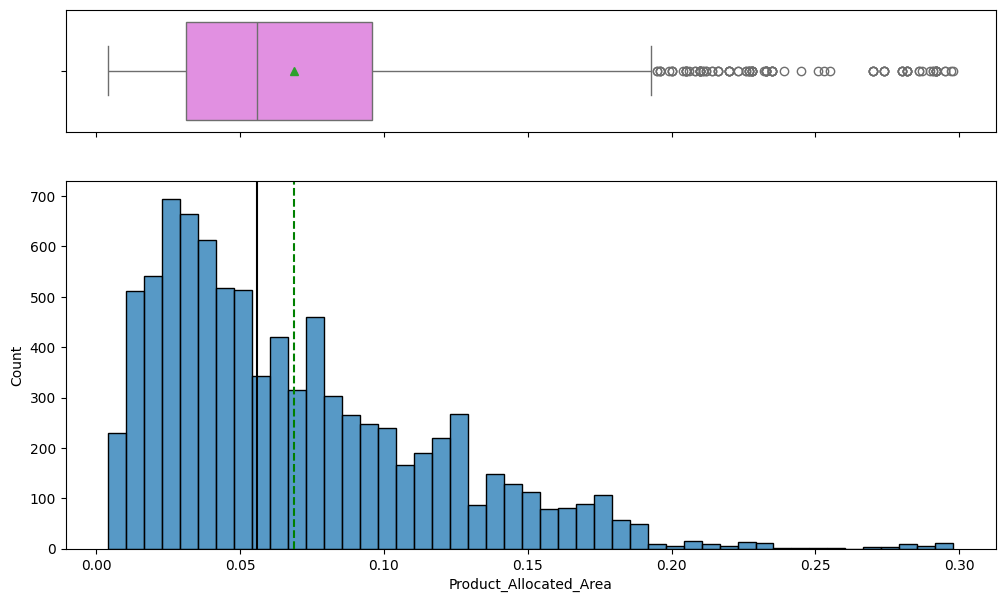

In [15]:
histogram_boxplot(data, "Product_Allocated_Area")

- The distribution is right skewed with the median lying around 0.05.

### **Product_MRP**

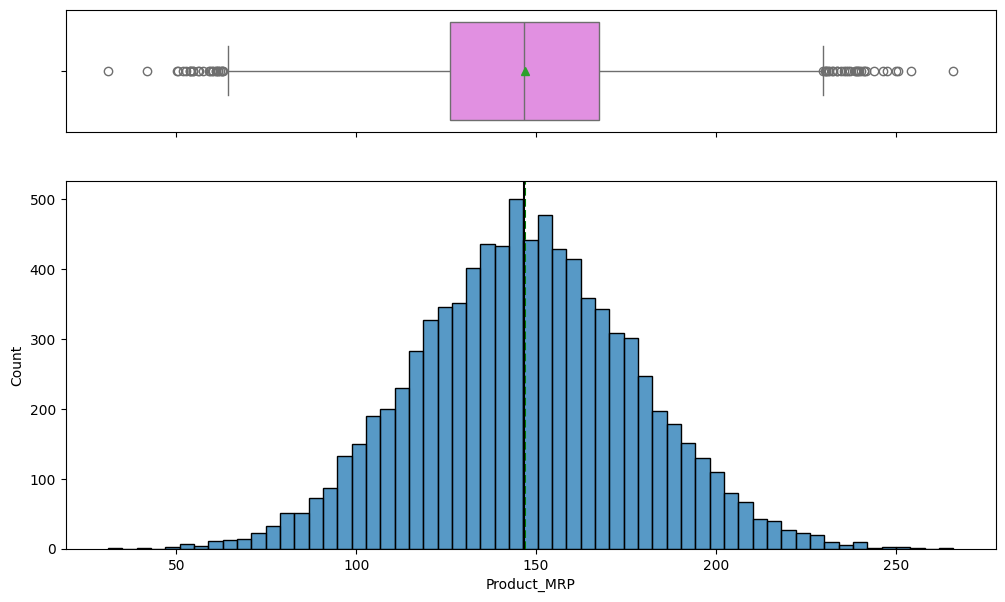

In [16]:
histogram_boxplot(data, "Product_MRP")

- The product MRP is normally distributed with mean and median lying around 150.

### **Product_Store_Sales_Total**

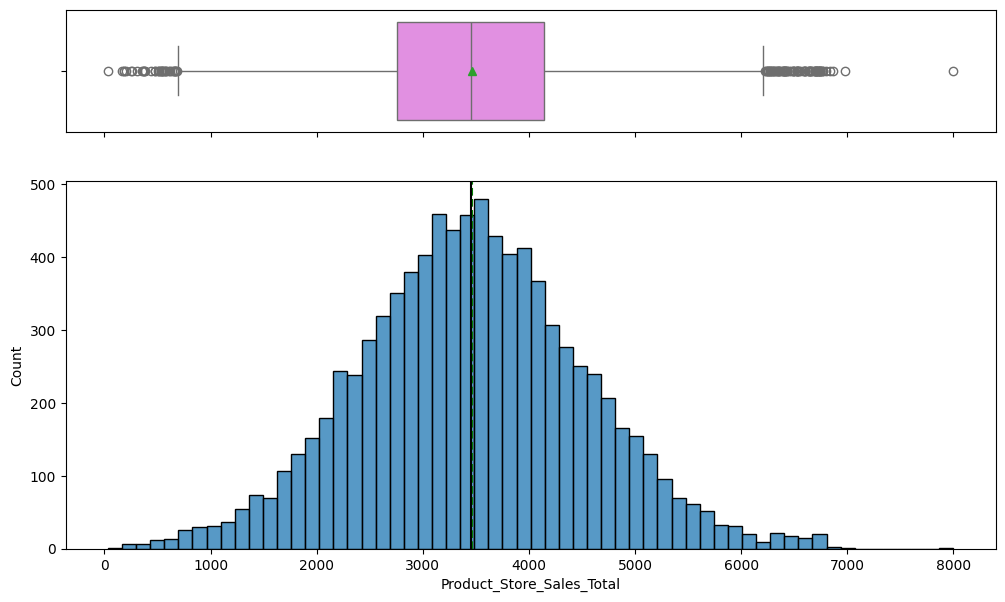

In [17]:
histogram_boxplot(data, "Product_Store_Sales_Total")

- The revenue generated from each product at a particular store is normally distributed with mean and median lying around 3500.

In [18]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

### **Product_Sugar_Content**

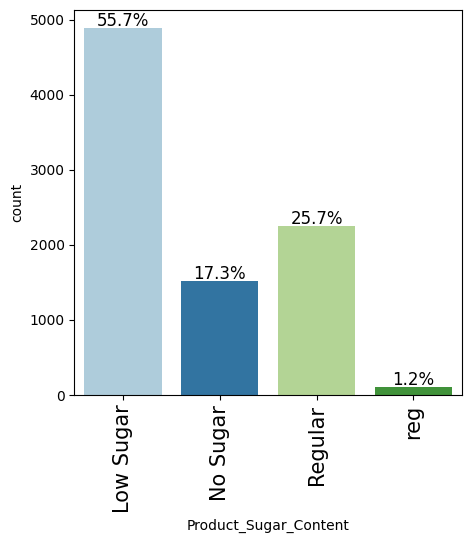

In [19]:
labeled_barplot(data, "Product_Sugar_Content", perc=True)

- Around 56% of the products are having low sugar followed by 27% products which are having regular sugar content.

- Note: reg is Regular

### **Product_Type**

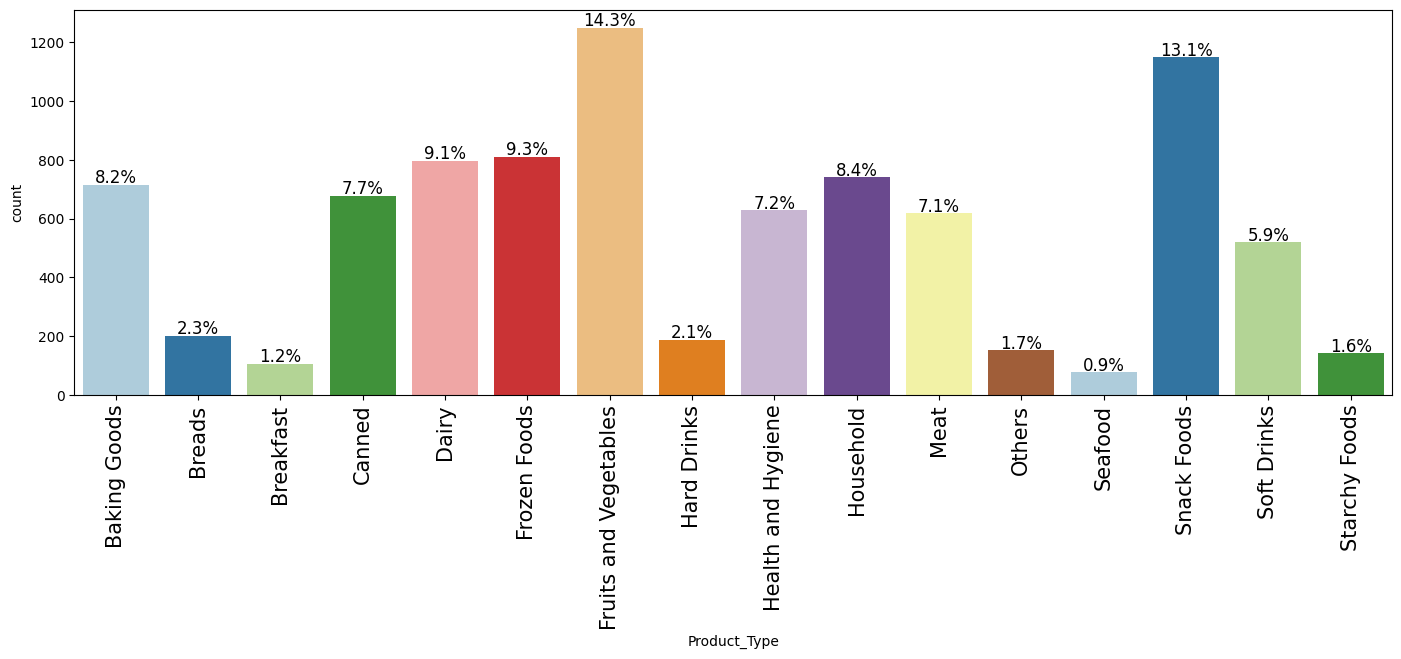

In [20]:
labeled_barplot(data, "Product_Type", perc=True)

- Fruits and vegetables (~ 14%) and Snack Foods (~ 13%) have been bought the highest number of times from all the stores combined.
- Seafood (~ 1%) has been bought the lowest number of times.

### **Store_Id**

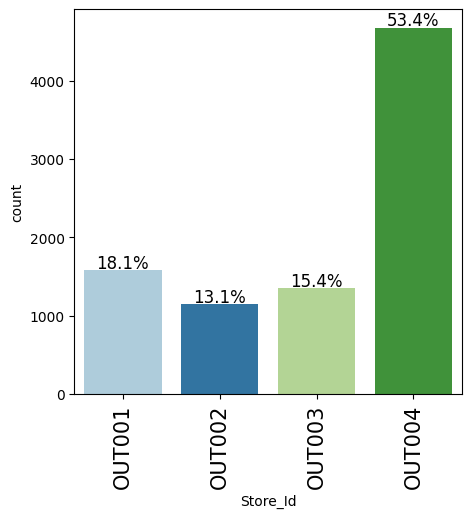

In [21]:
labeled_barplot(data, "Store_Id", perc=True)

- Around 53% of the products are being sold from outlet OUT004. Almost equal number of products have been sold from the other three stores each.

### **Store_Size**

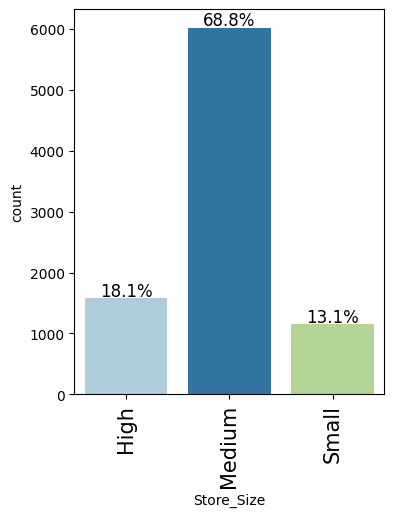

In [22]:
labeled_barplot(data, "Store_Size", perc=True)

- Around 69% of the products have been sold from the stores which are medium in size

### **Store_Location_City_Type**

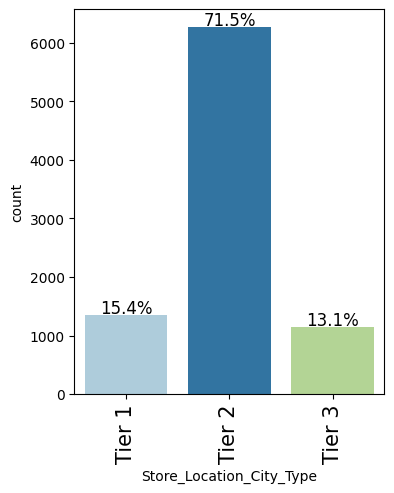

In [23]:
labeled_barplot(data, "Store_Location_City_Type", perc=True)

- Around 72% of the products have been sold from the stores which are located in the Tier 2 cities.

### **Store_Type**

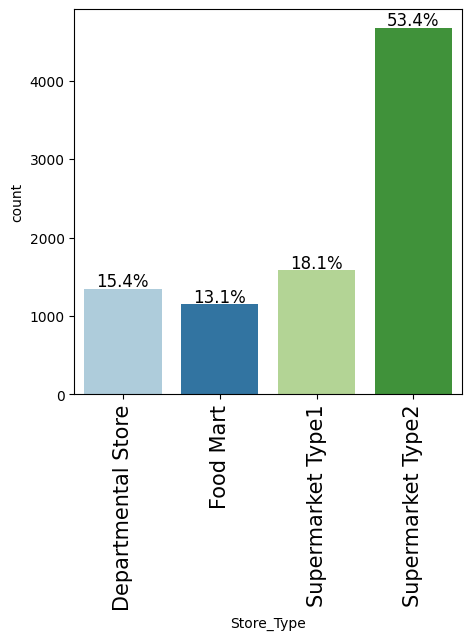

In [24]:
labeled_barplot(data, "Store_Type", perc=True)

- Around 53% of the products have been sold from stores which are of Supermarket Type2.

## Bivariate Analysis

### **Correlation matrix**

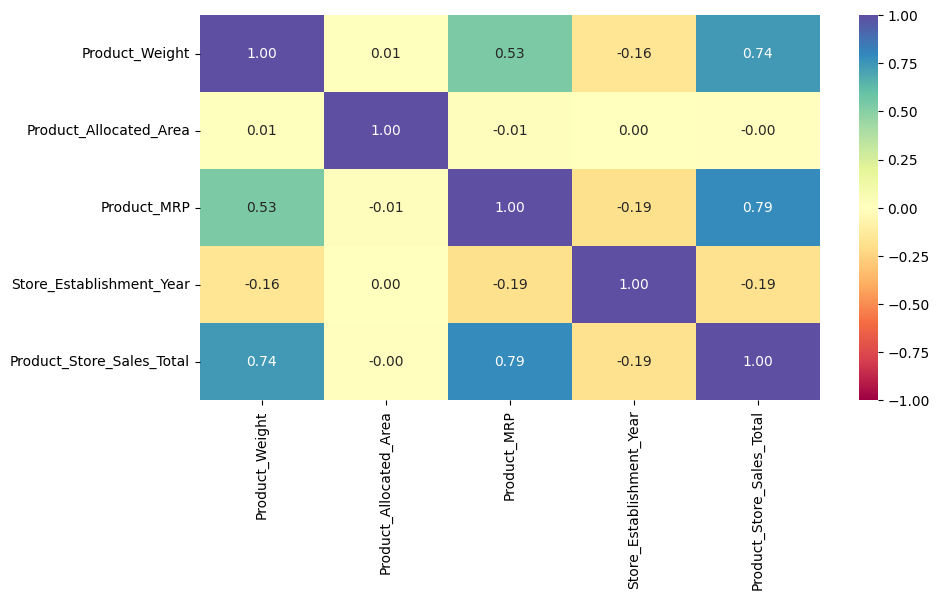

In [25]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

- Product weight and product MRP are highly correlated with our target variable i.e Product_Store_Sales_Total
- Product weight and product MRP are moderately correlated with each other.
- There is not much correlation among the rest of the variables.

### **Let's check the distribution of our target variable i.e Product_Store_Sales_Total with the numeric columns**

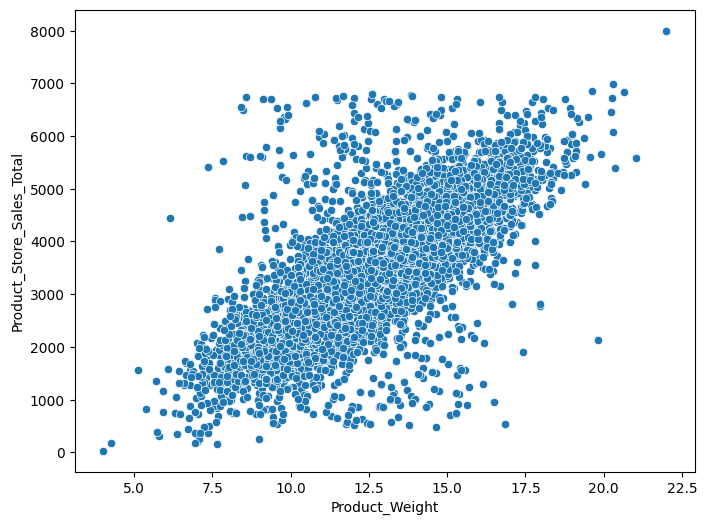

In [26]:
plt.figure(figsize=[8, 6])
sns.scatterplot(x=data.Product_Weight, y=data.Product_Store_Sales_Total)
plt.show()

- Product_Weight and Product_Store_Sales_Total are almost linearly correlated with each other.  

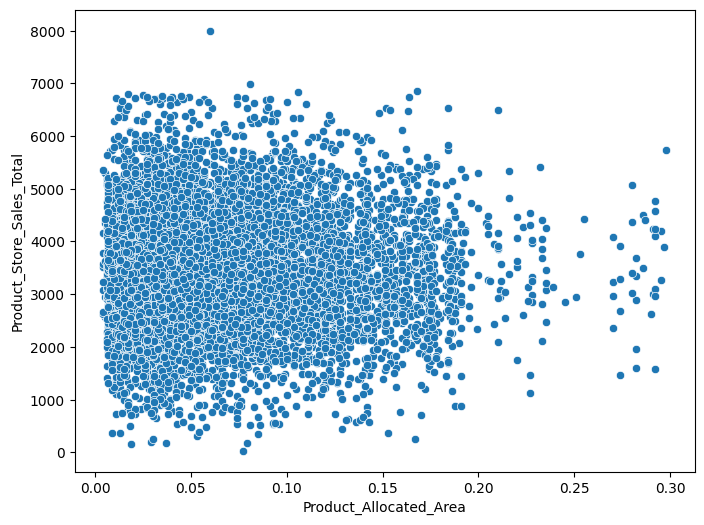

In [27]:
plt.figure(figsize=[8, 6])
sns.scatterplot(x=data.Product_Allocated_Area, y=data.Product_Store_Sales_Total)
plt.show()

- There seem to be no relationship between Product_Allocated_Area and Product_Store_Sales_Total.

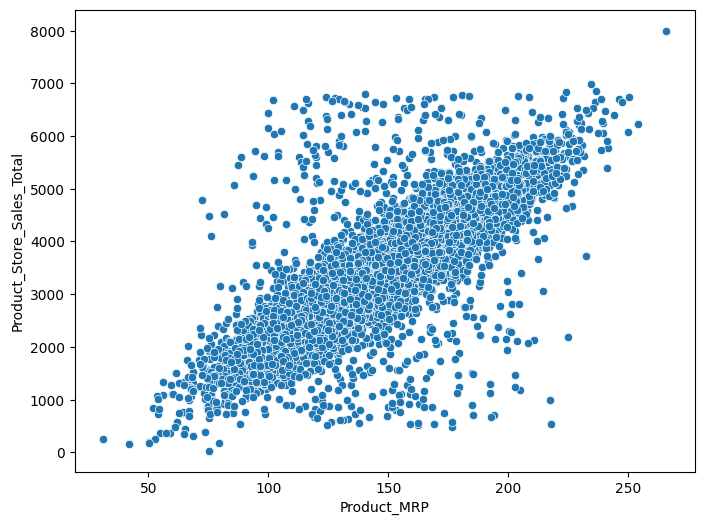

In [28]:
plt.figure(figsize=[8, 6])
sns.scatterplot(x=data.Product_MRP, y=data.Product_Store_Sales_Total)
plt.show()

- Product_MRP and Product_Store_Sales_Total are almost linearly correlated with each other.

### **Let us see from which product type the company is generating most of the revenue**

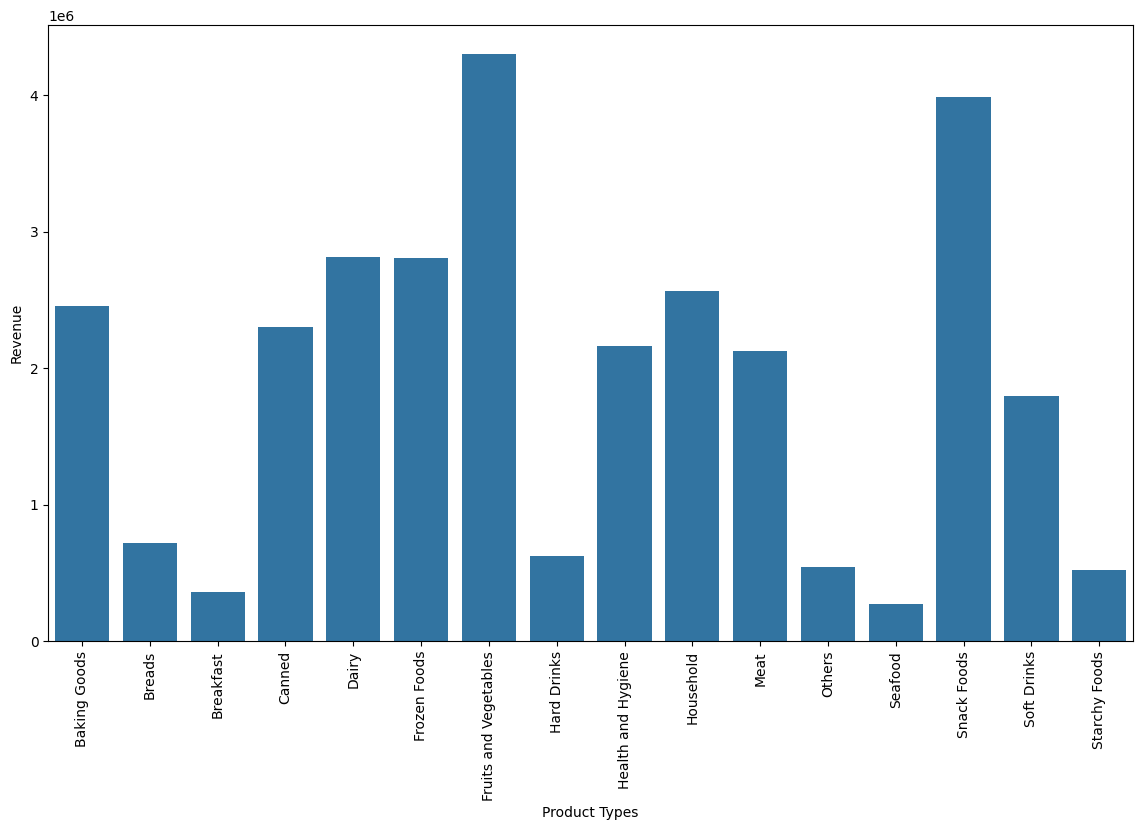

In [29]:
df_revenue1 = data.groupby(["Product_Type"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
a = sns.barplot(x=df_revenue1.Product_Type, y=df_revenue1.Product_Store_Sales_Total)
a.set_xlabel("Product Types")
a.set_ylabel("Revenue")
plt.show()

- Fruits and vegetables and snack foods are the biggest contributors to the revenue of the company(SuperKart).

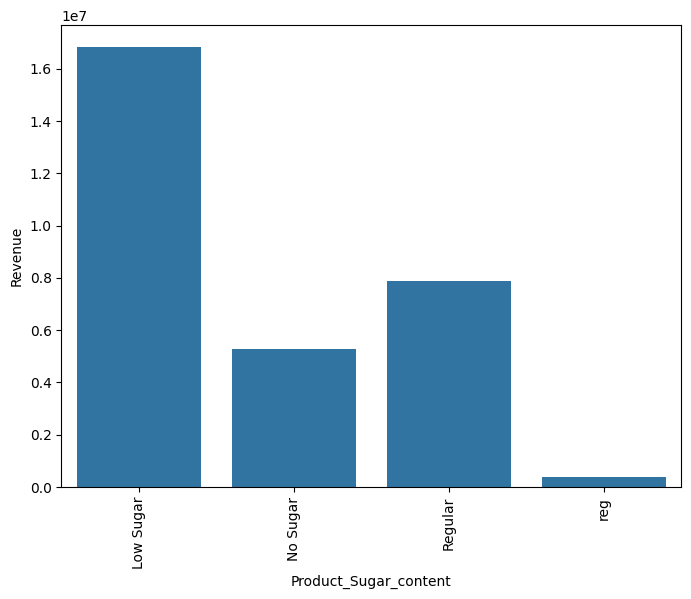

In [30]:
df_revenue2 = data.groupby(["Product_Sugar_Content"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
b = sns.barplot(
    x=df_revenue2.Product_Sugar_Content, y=df_revenue2.Product_Store_Sales_Total
)
b.set_xlabel("Product_Sugar_content")
b.set_ylabel("Revenue")
plt.show()

- Low sugar content materials are the biggest contributors to the revenue of the company(SuperKart).

### **Let us see from which type of stores and locations the revenue generation is more**.

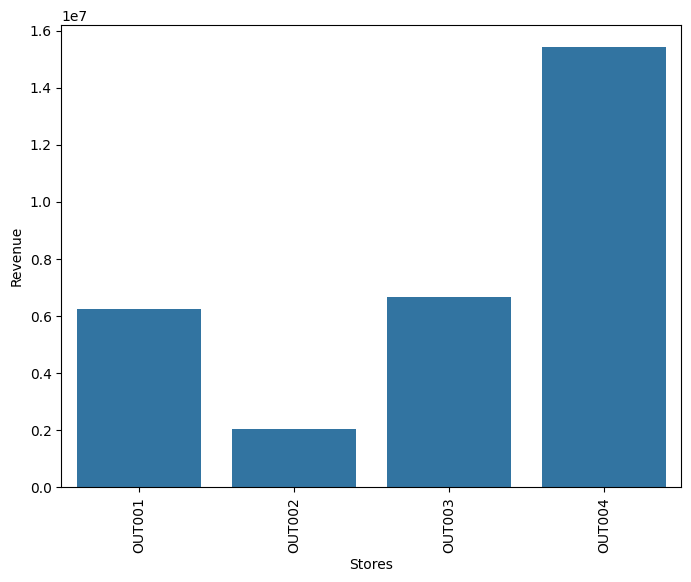

In [31]:
df_store_revenue = data.groupby(["Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
r = sns.barplot(
    x=df_store_revenue.Store_Id, y=df_store_revenue.Product_Store_Sales_Total
)
r.set_xlabel("Stores")
r.set_ylabel("Revenue")
plt.show()

- OUTOO4 is contributing the most to the revenue of the company which is more than double of the contribution being made by second-placed store OUT003.

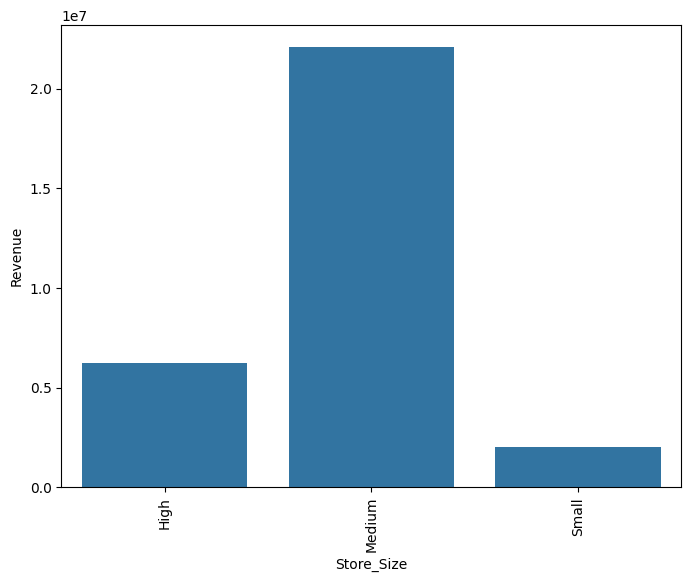

In [32]:
df_revenue3 = data.groupby(["Store_Size"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
c = sns.barplot(x=df_revenue3.Store_Size, y=df_revenue3.Product_Store_Sales_Total)
c.set_xlabel("Store_Size")
c.set_ylabel("Revenue")
plt.show()

- The medium sized stores are contributing heavily to the revenue.

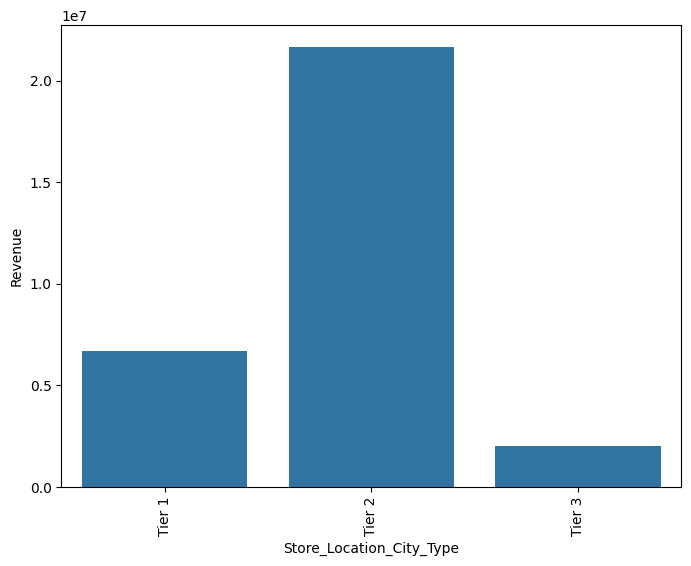

In [33]:
df_revenue4 = data.groupby(["Store_Location_City_Type"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
d = sns.barplot(
    x=df_revenue4.Store_Location_City_Type, y=df_revenue4.Product_Store_Sales_Total
)
d.set_xlabel("Store_Location_City_Type")
d.set_ylabel("Revenue")
plt.show()

- Stores in the Tier 2 cities are contributing the most to the revenue of SuperKart.

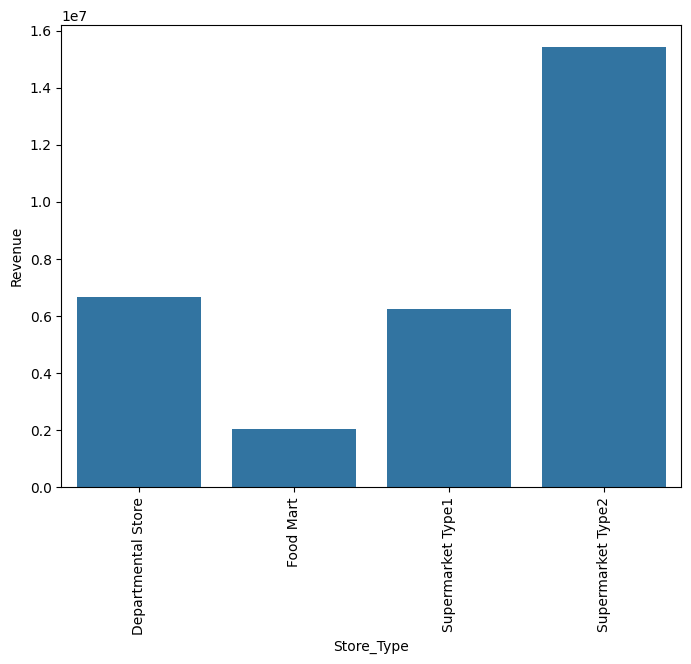

In [34]:
df_revenue5 = data.groupby(["Store_Type"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
e = sns.barplot(x=df_revenue5.Store_Type, y=df_revenue5.Product_Store_Sales_Total)
e.set_xlabel("Store_Type")
e.set_ylabel("Revenue")
plt.show()

- Stores of Supermarket Type 2 are performing exceptionally well.

### **Let's check the distribution of our target variable i.e Product_Store_Sales_Total with the other categorical columns**

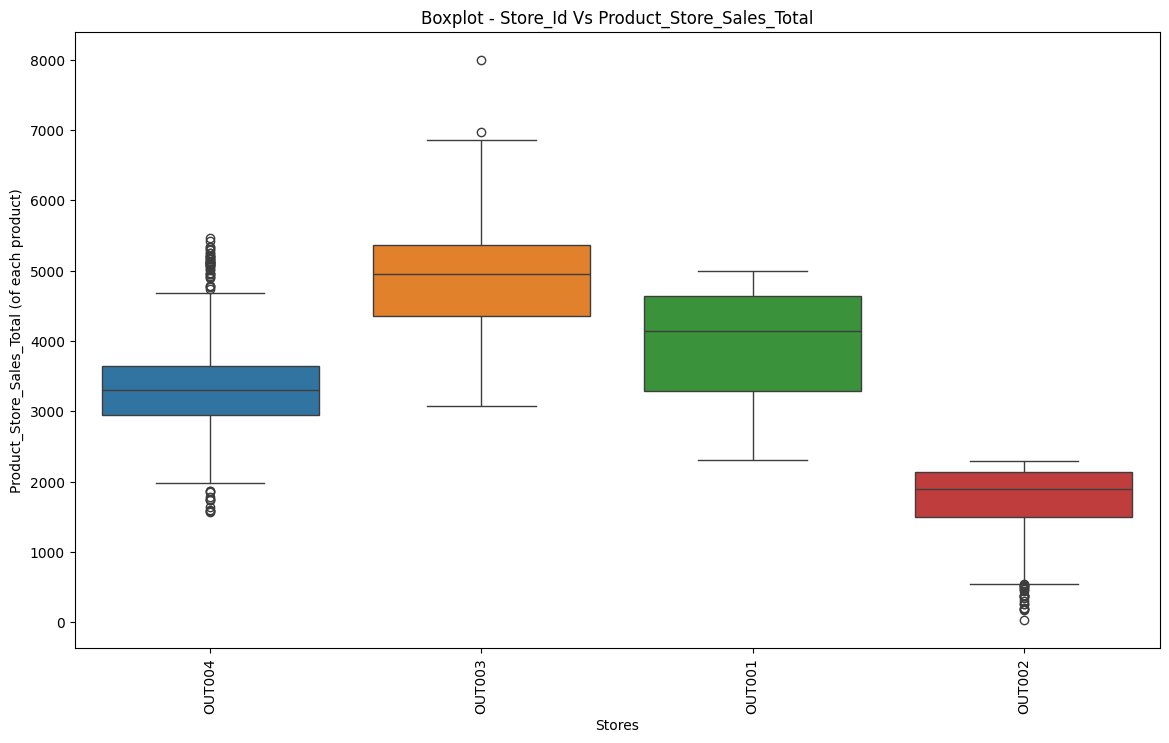

In [35]:
plt.figure(figsize=[14, 8])
sns.boxplot(data=data, x="Store_Id", y="Product_Store_Sales_Total", hue = "Store_Id")
plt.xticks(rotation=90)
plt.title("Boxplot - Store_Id Vs Product_Store_Sales_Total")
plt.xlabel("Stores")
plt.ylabel("Product_Store_Sales_Total (of each product)")
plt.show()

- Although the number of products bought from OUT003 is around 15% only, however more costly goods have been bought from this store than the other stores. This shows that this is a premium store for the company.

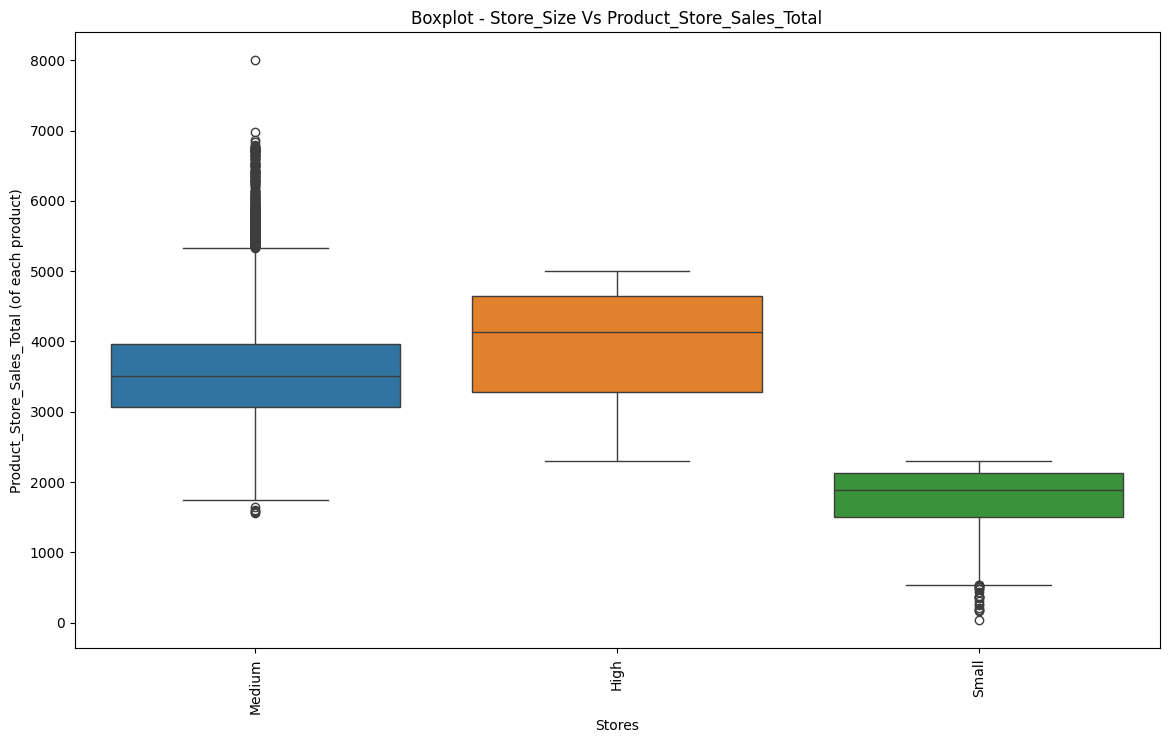

In [36]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Store_Size", y = "Product_Store_Sales_Total", hue = "Store_Size")
plt.xticks(rotation=90)
plt.title("Boxplot - Store_Size Vs Product_Store_Sales_Total")
plt.xlabel("Stores")
plt.ylabel("Product_Store_Sales_Total (of each product)")
plt.show()

- More costly goods have been bought from the stores which are high in size which seems to be quite logical.

### **Let's now try to find out some relationship between the other columns**

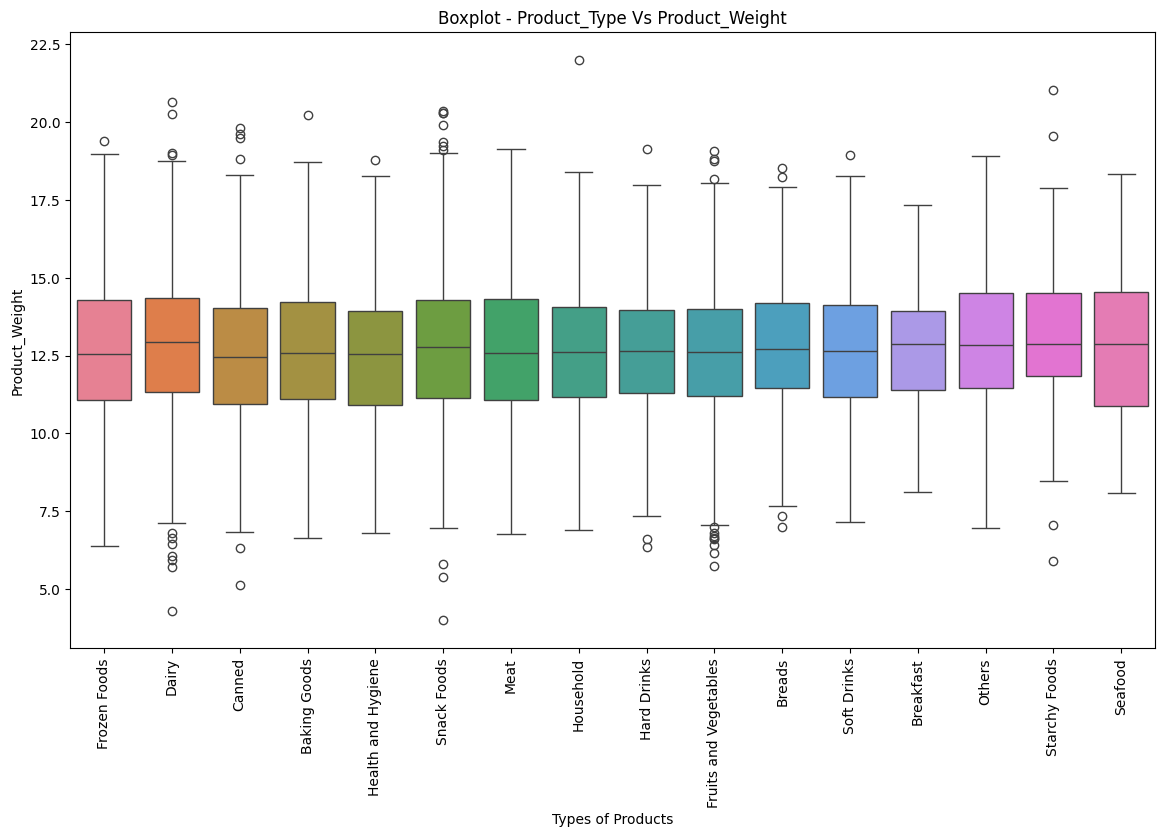

In [37]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Product_Type", y = "Product_Weight", hue = "Product_Type")
plt.xticks(rotation=90)
plt.title("Boxplot - Product_Type Vs Product_Weight")
plt.xlabel("Types of Products")
plt.ylabel("Product_Weight")
plt.show()

- The median weight of all the product types is almost equal. Each product type contains different items whose weight ranges from low to high, therefore the overall weight of the product category gets averaged out.

### **Let's find out whether there is some relationship between the weight of the product and its sugar content**

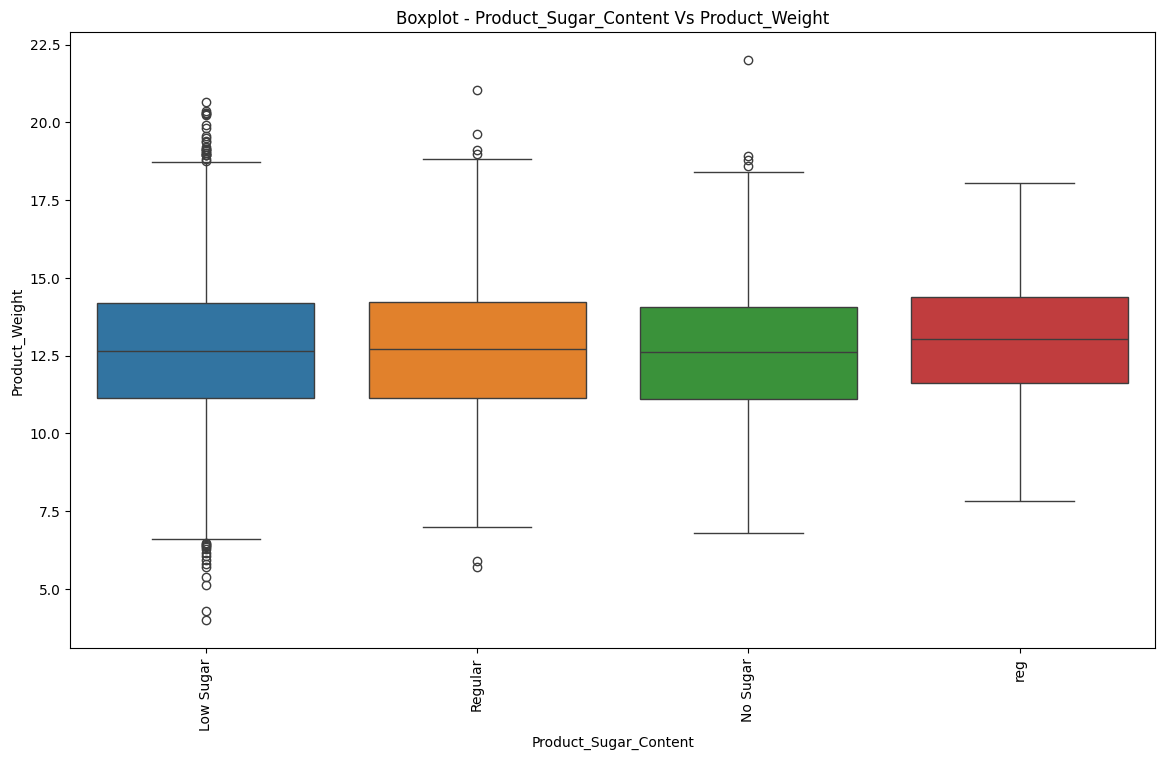

In [38]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Product_Sugar_Content", y = "Product_Weight", hue = "Product_Sugar_Content")
plt.xticks(rotation=90)
plt.title("Boxplot - Product_Sugar_Content Vs Product_Weight")
plt.xlabel("Product_Sugar_Content")
plt.ylabel("Product_Weight")
plt.show()

- The median weight of all the products across the 3 categories is almost the same.

### **Let's analyze the sugar content of different product types**

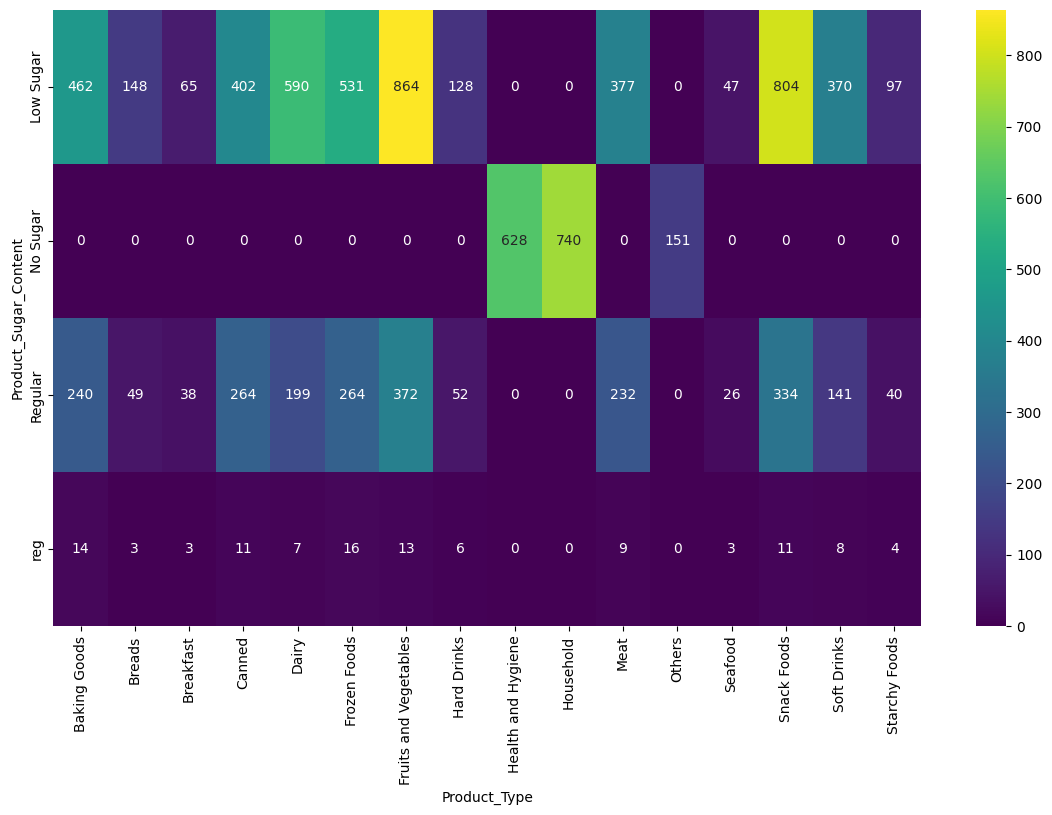

In [39]:
plt.figure(figsize=(14, 8))
sns.heatmap(
    pd.crosstab(data["Product_Sugar_Content"], data["Product_Type"]),
    annot=True,
    fmt="g",
    cmap="viridis",
)
plt.ylabel("Product_Sugar_Content")
plt.xlabel("Product_Type")
plt.show()

- Health and hygiene, household and others are the only categories which have no sugar in them.

### **Let's find out how many items of each product type has been sold in each of the stores**

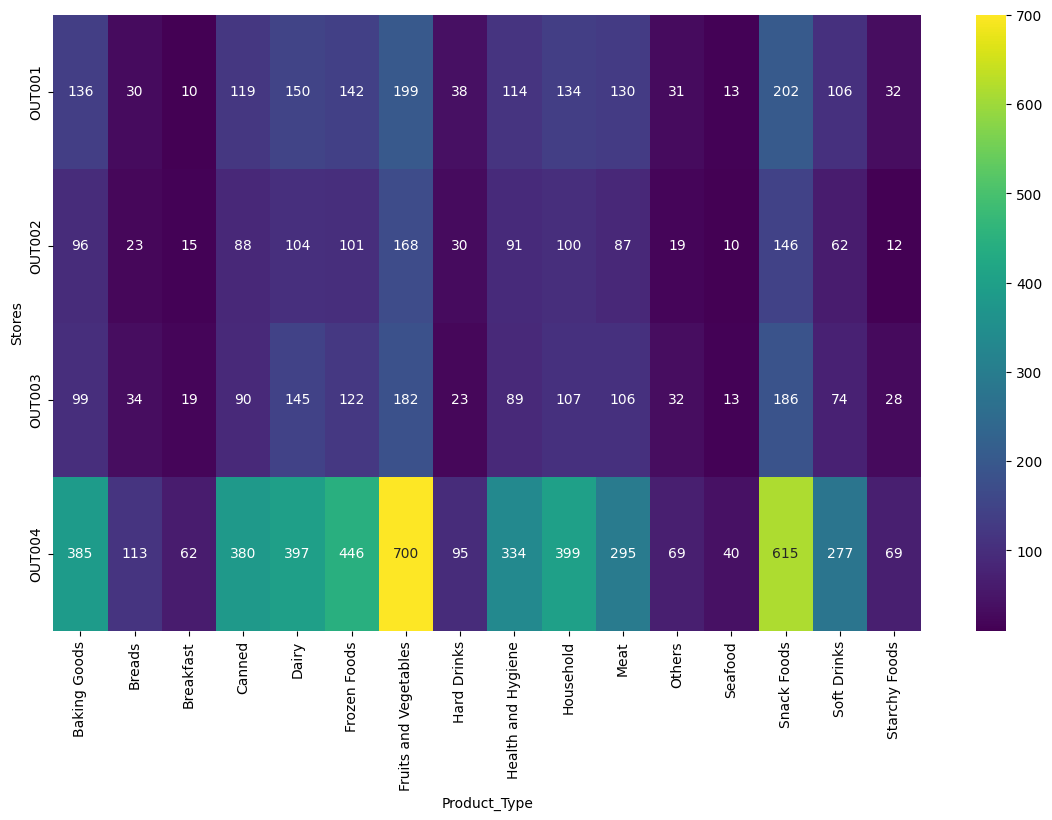

In [40]:
plt.figure(figsize=(14, 8))
sns.heatmap(
    pd.crosstab(data["Store_Id"], data["Product_Type"]),
    annot=True,
    fmt="g",
    cmap="viridis",
)
plt.ylabel("Stores")
plt.xlabel("Product_Type")
plt.show()

- Fruits and vegetables have been sold the most across all the stores followed by snack foods.
- Seafood is the least bought product type across all the stores

### **Different product types have different prices. Let's analyze the trend.**

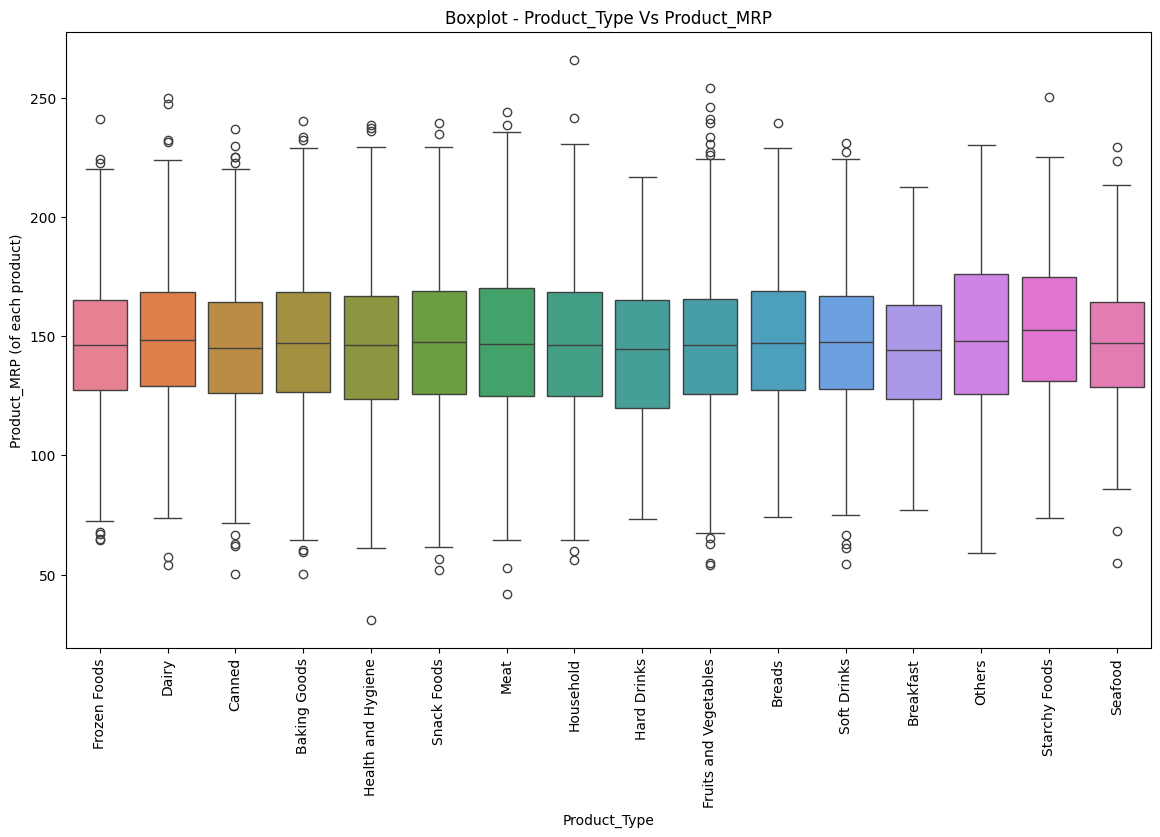

In [41]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Product_Type", y = "Product_MRP", hue = "Product_Type")
plt.xticks(rotation=90)
plt.title("Boxplot - Product_Type Vs Product_MRP")
plt.xlabel("Product_Type")
plt.ylabel("Product_MRP (of each product)")
plt.show()

- The median MRPs of all the product types are almost equal. Each product type contains differrent items whose price ranges from low to high, therefore the overall MRP of the product category gets averaged out.

### **Let's find out how the Product_MRP varies with the different stores**

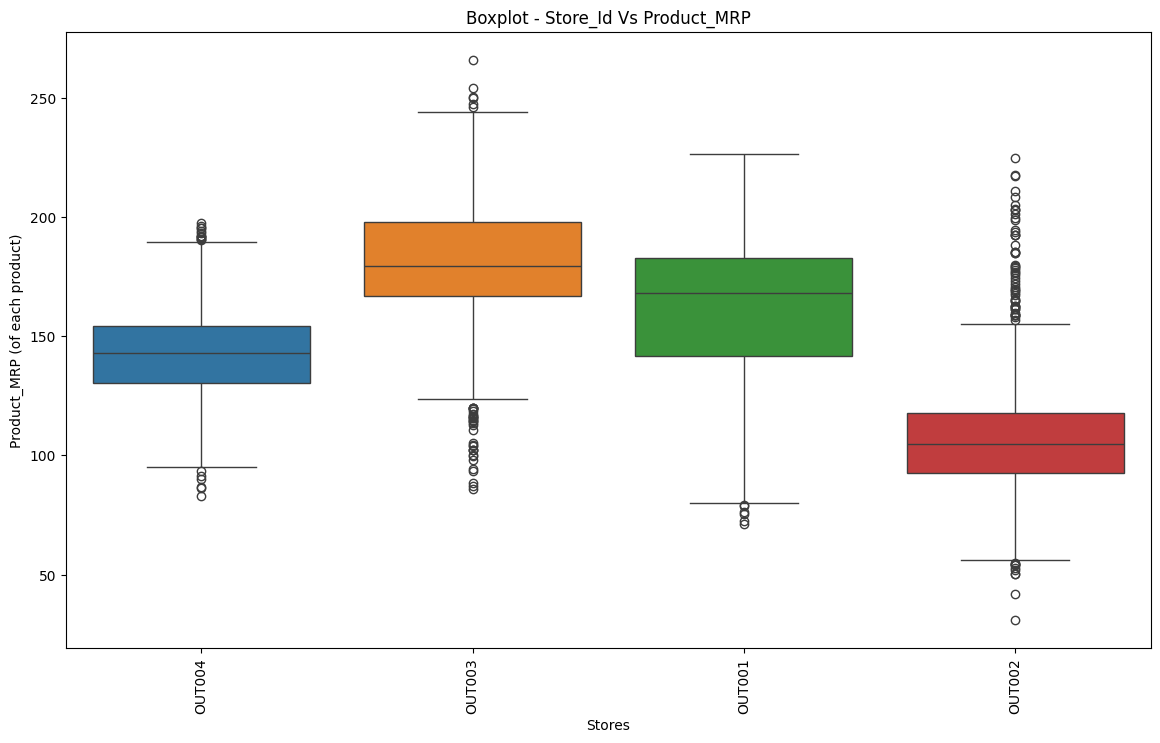

In [42]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Store_Id", y = "Product_MRP", hue = "Store_Id")
plt.xticks(rotation=90)
plt.title("Boxplot - Store_Id Vs Product_MRP")
plt.xlabel("Stores")
plt.ylabel("Product_MRP (of each product)")
plt.show()

- As we have seen earlier OUT003, being a premium store, has more costly items that the rest of the stores.

### **Let's delve deeper and do a detailed analysis of each of the stores**.

#### OUT001

In [43]:
data.loc[data["Store_Id"] == "OUT001"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,1586,1586,NC7187,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,1586.0,NaN,NaN,NaN,13.458865,2.064975,6.16,12.0525,13.96,14.95,17.97
Product_Sugar_Content,1586,4,Low Sugar,845,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1586.0,NaN,NaN,NaN,0.068768,0.047131,0.004,0.033,0.0565,0.094,0.295
Product_Type,1586,16,Snack Foods,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1586.0,NaN,NaN,NaN,160.514054,30.359059,71.35,141.72,168.32,182.9375,226.59
Store_Id,1586,1,OUT001,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1586.0,NaN,NaN,NaN,1987.0,0.0,1987.0,1987.0,1987.0,1987.0,1987.0
Store_Size,1586,1,High,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1586,1,Tier 2,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations**
- OUT001 is a store of Supermarket Type 1 which is located in a Tier 2 city and has store size as high. It was established in 1987.
- OUT001 has sold products whose MRP range from 71 to 227.
- Snack Foods have been sold the highest number of times in OUT001.
- The revenue generated from each product at OUT001 ranges from 2300 to 5000.

In [44]:
data.loc[data["Store_Id"] == "OUT001", "Product_Store_Sales_Total"].sum()

np.float64(6223113.18)

**OUT001 has generated total revenue of 6223113 from the sales of goods.**

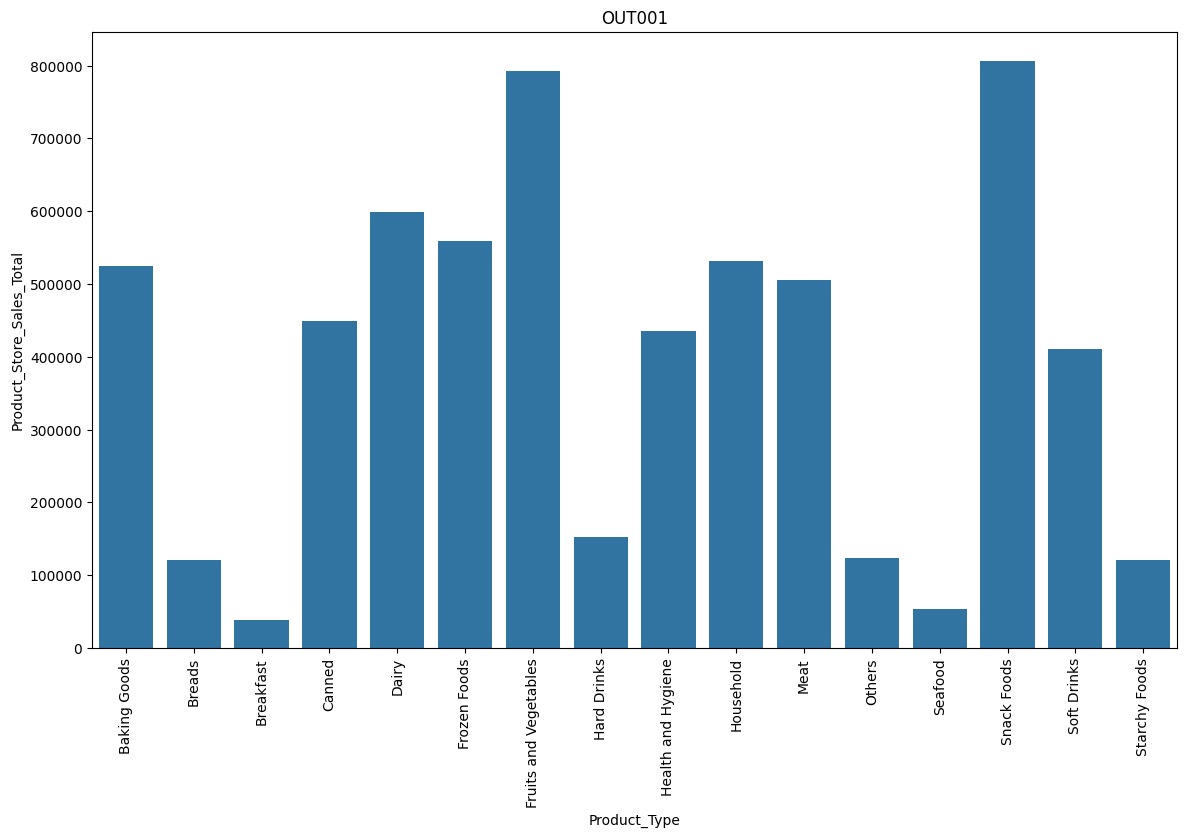

In [45]:
df_OUT001 = (
    data.loc[data["Store_Id"] == "OUT001"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT001")
sns.barplot(x=df_OUT001.Product_Type, y=df_OUT001.Product_Store_Sales_Total)
plt.show()

- OUT001 has generated the highest revenue from the sale of fruits and vegetables and snack foods. Both the categories have contributed around 800000 each.

#### OUT002

In [46]:
data.loc[data["Store_Id"] == "OUT002"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,1152,1152,NC2769,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,1152.0,NaN,NaN,NaN,9.911241,1.799846,4.0,8.7675,9.795,10.89,19.82
Product_Sugar_Content,1152,4,Low Sugar,658,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1152.0,NaN,NaN,NaN,0.067747,0.047567,0.006,0.031,0.0545,0.09525,0.292
Product_Type,1152,16,Fruits and Vegetables,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1152.0,NaN,NaN,NaN,107.080634,24.912333,31.0,92.8275,104.675,117.8175,224.93
Store_Id,1152,1,OUT002,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1152.0,NaN,NaN,NaN,1998.0,0.0,1998.0,1998.0,1998.0,1998.0,1998.0
Store_Size,1152,1,Small,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1152,1,Tier 3,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations**
- OUT002 is a food mart which is located in a Tier 3 city and has store size as small. It was established in 1998.
- OUT002 has sold products whose MRP range from 31 to 225.
- Fruits and vegetables have been sold the highest number of times in OUT002.
- The revenue generated from each product at OUT002 ranges from 33 to 2300.

In [47]:
data.loc[data["Store_Id"] == "OUT002", "Product_Store_Sales_Total"].sum()

np.float64(2030909.72)

**OUT002 has generated total revenue of 2030910 from the sales of goods.**

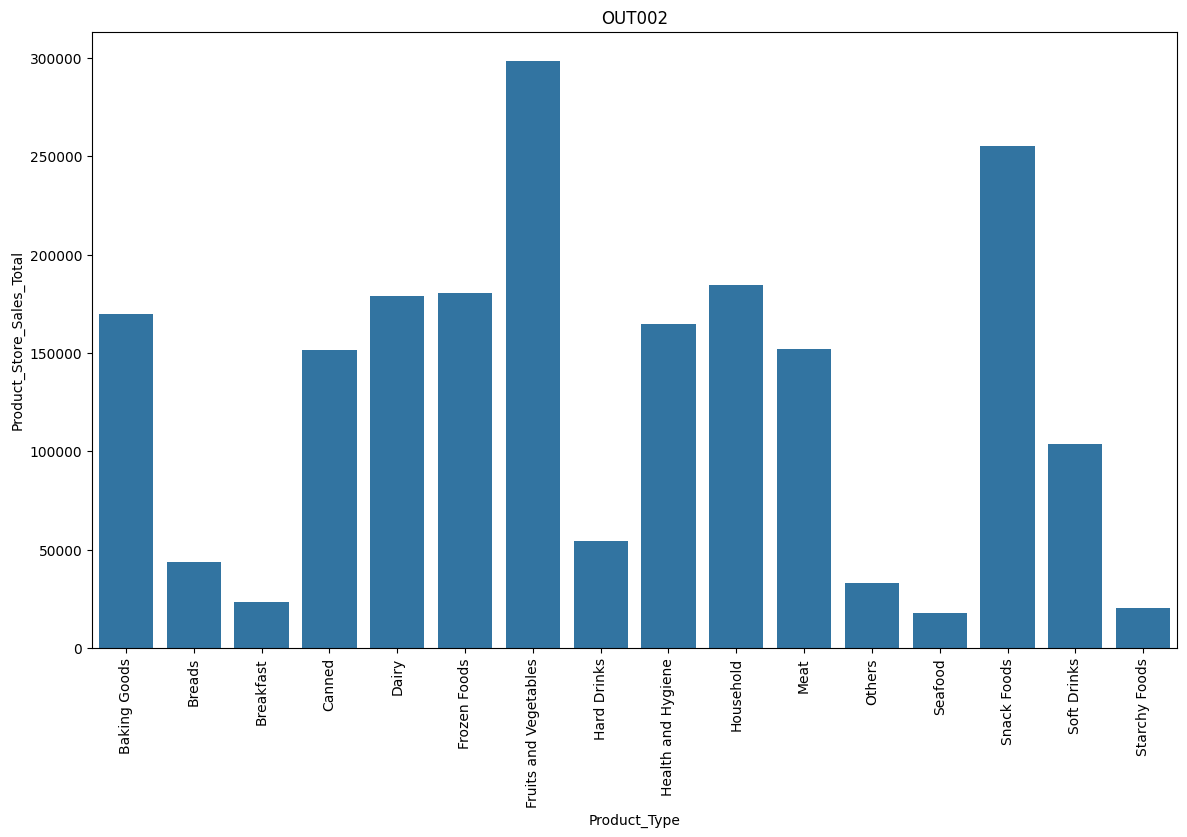

In [48]:
df_OUT002 = (
    data.loc[data["Store_Id"] == "OUT002"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT002")
sns.barplot(x=df_OUT002.Product_Type, y=df_OUT002.Product_Store_Sales_Total)
plt.show()

- OUT002 has generated the highest revenue from the sale of fruits and vegetables (~ 300000) followed by snack foods (~ 250000).

#### OUT003

In [49]:
data.loc[data["Store_Id"] == "OUT003"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,1349,1349,NC522,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,1349.0,NaN,NaN,NaN,15.103692,1.893531,7.35,14.02,15.18,16.35,22.0
Product_Sugar_Content,1349,4,Low Sugar,750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1349.0,NaN,NaN,NaN,0.068637,0.048708,0.004,0.031,0.057,0.094,0.298
Product_Type,1349,16,Snack Foods,186,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1349.0,NaN,NaN,NaN,181.358725,24.796429,85.88,166.92,179.67,198.07,266.0
Store_Id,1349,1,OUT003,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1349.0,NaN,NaN,NaN,1999.0,0.0,1999.0,1999.0,1999.0,1999.0,1999.0
Store_Size,1349,1,Medium,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1349,1,Tier 1,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations**
- OUT003 is a Departmental store which is located in a Tier 1 city and has store size as medium. It was established in 1999.
- OUT003 has sold products whose MRP range from 86 to 266.
- Snack Foods have been sold the highest number of times in OUT003.
- The revenue generated from each product at OUT003 ranges from 3070 to 8000.

In [50]:
data.loc[data["Store_Id"] == "OUT003", "Product_Store_Sales_Total"].sum()

np.float64(6673457.57)

**OUT003 has generated total revenue of 6673458 from the sales of goods.**

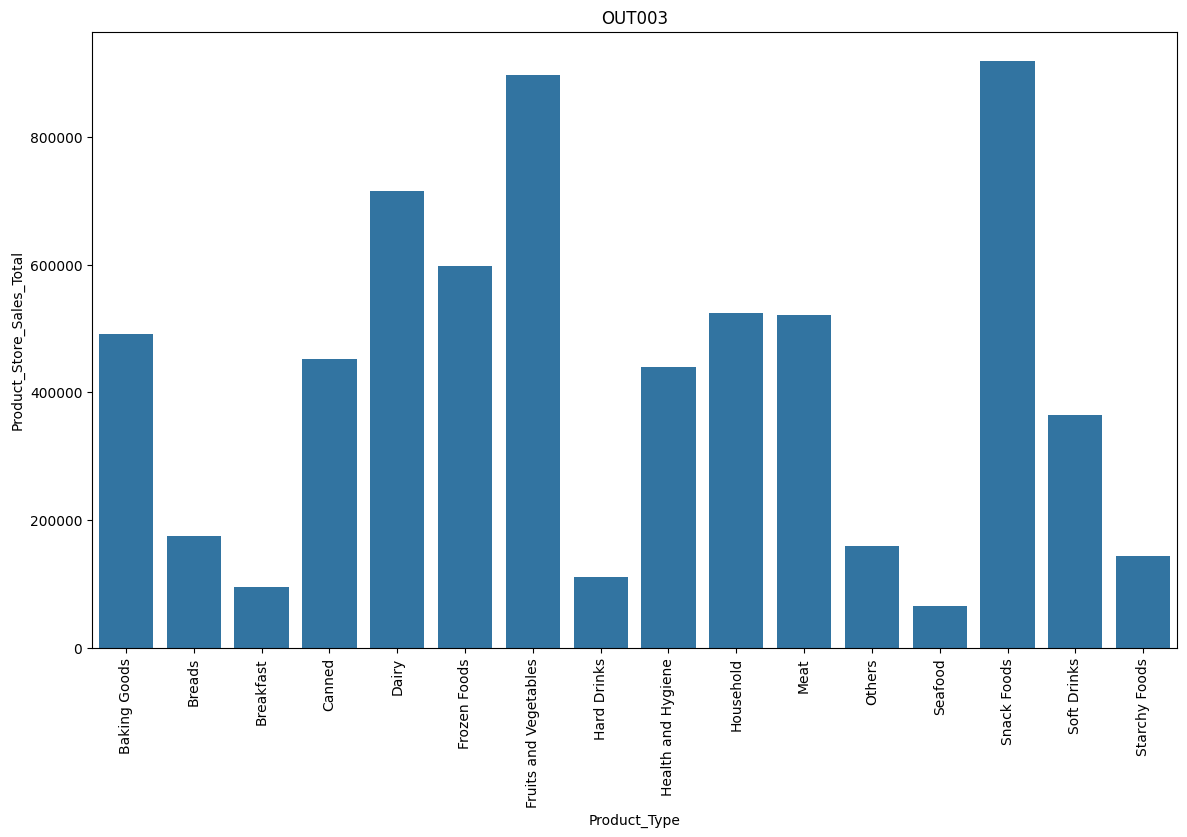

In [51]:
df_OUT003 = (
    data.loc[data["Store_Id"] == "OUT003"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT003")
sns.barplot(x=df_OUT003.Product_Type, y=df_OUT003.Product_Store_Sales_Total)
plt.show()

- OUT003 has generated the highest revenue from the sale of snack foods followed by fruits and vegetables, both the categories contributing around 800000 each.

#### OUT004

In [52]:
data.loc[data["Store_Id"] == "OUT004"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,4676,4676,NC584,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,4676.0,NaN,NaN,NaN,12.349613,1.428199,7.34,11.37,12.37,13.3025,17.79
Product_Sugar_Content,4676,4,Low Sugar,2632,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,4676.0,NaN,NaN,NaN,0.069092,0.048584,0.004,0.031,0.056,0.097,0.297
Product_Type,4676,16,Fruits and Vegetables,700,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,4676.0,NaN,NaN,NaN,142.399709,17.513973,83.04,130.54,142.82,154.1925,197.66
Store_Id,4676,1,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,4676.0,NaN,NaN,NaN,2009.0,0.0,2009.0,2009.0,2009.0,2009.0,2009.0
Store_Size,4676,1,Medium,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,4676,1,Tier 2,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations**
- OUT004 is a store of Supermarket Type2 which is located in a Tier 2 city and has store size as medium. It was established in 2009.
- OUT004 has sold products whose MRP range from 83 to 198.
- Fruits and vegetables have been sold the highest number of times in OUT004.
- The revenue generated from each product at OUT004 ranges from 1561 to 5463.

In [53]:
data.loc[data["Store_Id"] == "OUT004", "Product_Store_Sales_Total"].sum()

np.float64(15427583.43)

**OUT004 has generated total revenue of 15427583 from the sales of goods which is highest among all the 4 stores.**

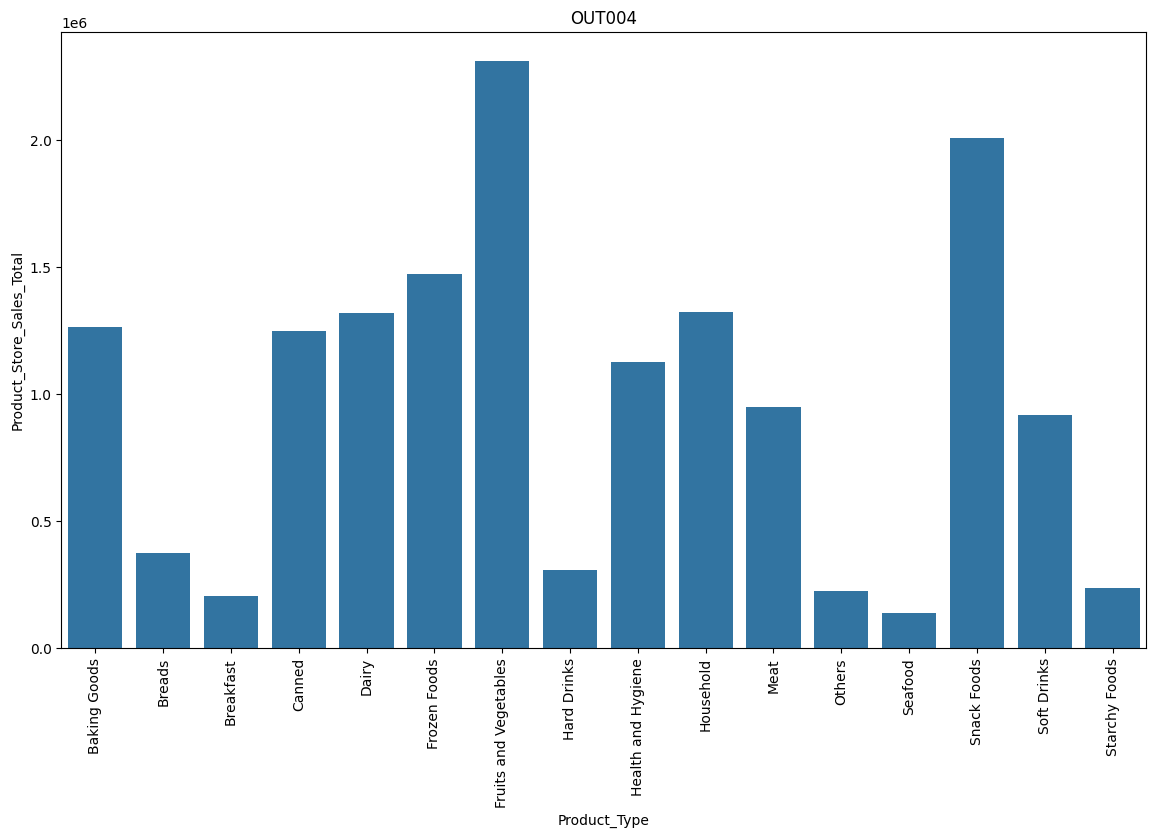

In [54]:
df_OUT004 = (
    data.loc[data["Store_Id"] == "OUT004"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT004")
sns.barplot(x=df_OUT004.Product_Type, y=df_OUT004.Product_Store_Sales_Total)
plt.show()

- OUT004 has generated the highest revenue from the sale of fruits and vegetables (~ 2500000) followed by snack foods (~ 2000000).

**Let's find out the revenue generated by the stores from each of the product types**.

In [55]:
df1 = data.groupby(["Product_Type", "Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
df1

,Product_Type,Store_Id,Product_Store_Sales_Total
0,Baking Goods,OUT001,525131.04
1,Baking Goods,OUT002,169860.50
2,Baking Goods,OUT003,491908.20
3,Baking Goods,OUT004,1266086.26
4,Breads,OUT001,121274.09
5,Breads,OUT002,43419.47
6,Breads,OUT003,175391.93
7,Breads,OUT004,374856.75
8,Breakfast,OUT001,38161.10
9,Breakfast,OUT002,23396.10


- In all the product types, the revenue generated by OUT004 has been the highest which seems quite logical since around 53% of the total products were brought from this store.
- In all the product categories, the revenue generated by OUT002 has been the lowest which seems quite obvious since it is small store in a Tier 3 city.

**Let's find out the revenue generated by the stores from products having different levels of sugar content**.

In [56]:
df2 = data.groupby(["Product_Sugar_Content", "Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
df2

,Product_Sugar_Content,Store_Id,Product_Store_Sales_Total
0,Low Sugar,OUT001,3300834.93
1,Low Sugar,OUT002,1156758.85
2,Low Sugar,OUT003,3706903.24
3,Low Sugar,OUT004,8658908.78
4,No Sugar,OUT001,1090353.78
5,No Sugar,OUT002,382162.19
6,No Sugar,OUT003,1123084.57
7,No Sugar,OUT004,2674343.14
8,Regular,OUT001,1749444.51
9,Regular,OUT002,472112.50


- The trend is the same as that which was present in the revenue analysis of stores for product types.

# **Data Preprocessing**

## **Replacing the values in the Product_Sugar_Content column**

We can observe that in the Product_Sugar_Content column, there are 3 types - Low Sugar, Regular and reg.

It seems quite obvious that Regular and reg are referring to the same category. So let's replace reg with Regular.

In [57]:
# Replacing reg with Regular
data.Product_Sugar_Content.replace(to_replace=["reg"], value=["Regular"], inplace=True)

In [58]:
data.Product_Sugar_Content.value_counts()

,count
Product_Sugar_Content,
Low Sugar,4885
Regular,2359
No Sugar,1519


## **Exploring Patterns in Product_IDs**

We can see that the Product_Id column has two characters followed by a number.

Let's delve deeper and see whether they are having any relationship with the other columns or not

In [59]:
## extracting the first two characters from the Product_Id column and storing it in another column
data["Product_Id_char"] = data["Product_Id"].str[:2]
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC


In [60]:
data["Product_Id_char"].unique()

array(['FD', 'NC', 'DR'], dtype=object)

In [61]:
data.loc[data.Product_Id_char == "FD", "Product_Type"].unique()

array(['Frozen Foods', 'Dairy', 'Canned', 'Baking Goods', 'Snack Foods',
       'Meat', 'Fruits and Vegetables', 'Breads', 'Breakfast',
       'Starchy Foods', 'Seafood'], dtype=object)

- We can see that FD is being used in the Product_Id of the food items.

In [62]:
data.loc[data.Product_Id_char == "DR", "Product_Type"].unique()

array(['Hard Drinks', 'Soft Drinks'], dtype=object)

- We can see that DR is being used in the Product_Id of the drinks.

In [63]:
data.loc[data.Product_Id_char == "NC", "Product_Type"].unique()

array(['Health and Hygiene', 'Household', 'Others'], dtype=object)

- We can see that NC is being used in the Product_Id of other items.

## **Store's Age**

A store which has been in the business for a long duration is more trustworthy than the newly established ones.

On the other hand, older stores may sometimes lack infrastructure if proper attention is not given. So let us calculate the current age of the store and incorporate that in our model.

In [64]:
# Outlet Age
data["Store_Age_Years"] = 2025 - data.Store_Establishment_Year

## **Grouping Product Types into Perishables and Non-Perishables.**

We have 16 different product types in our dataset.

So let us make two broad categories, perishables and non perishables, in order to reduce the number of product types

In [65]:
perishables = [
    "Dairy",
    "Meat",
    "Fruits and Vegetables",
    "Breakfast",
    "Breads",
    "Seafood",
]

In [66]:
def change(x):
    if x in perishables:
        return "Perishables"
    else:
        return "Non Perishables"


data.Product_Type.apply(change)

,Product_Type
0,Non Perishables
1,Perishables
2,Non Perishables
3,Non Perishables
4,Non Perishables
...,...
8758,Non Perishables
8759,Non Perishables
8760,Non Perishables
8761,Non Perishables


In [67]:
data['Product_Type_Category'] = data['Product_Type'].apply(change)

In [68]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD,16,Non Perishables
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD,26,Perishables
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD,38,Non Perishables
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD,38,Non Perishables
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC,27,Non Perishables


## **Outlier Check**

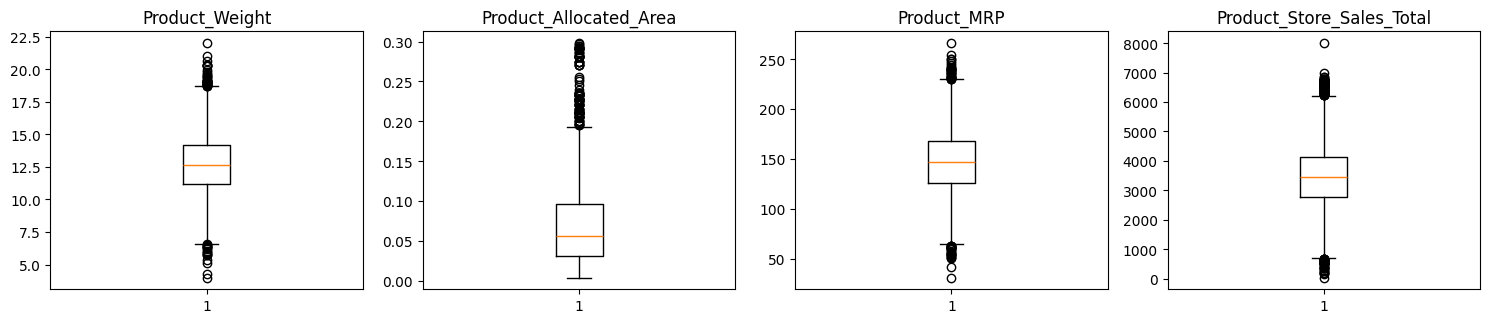

In [69]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()
numeric_columns.remove("Store_Establishment_Year")
numeric_columns.remove("Store_Age_Years")


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

**Observations**

- There are quite a few outliers in the data.
- However, we will not treat them as they are proper values.

## **Data Preparation for Modeling**

- We aim to forecast the Product_Store_Sales_Total.

- Before building the model, we'll drop unnecessary columns and encode the categorical features.

- We'll then split the data into training and testing sets to evaluate the model's performance on unseen data.

In [70]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD,16,Non Perishables
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD,26,Perishables
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD,38,Non Perishables
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD,38,Non Perishables
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC,27,Non Perishables


Let's remove the columns that are not required.

In [71]:
data = data.drop(["Product_Id","Product_Type","Store_Id","Store_Establishment_Year"], axis=1)

In [72]:
data.shape

(8763, 11)

In [73]:
data.head()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,12.66,Low Sugar,0.027,117.08,Medium,Tier 2,Supermarket Type2,2842.40,FD,16,Non Perishables
1,16.54,Low Sugar,0.144,171.43,Medium,Tier 1,Departmental Store,4830.02,FD,26,Perishables
2,14.28,Regular,0.031,162.08,High,Tier 2,Supermarket Type1,4130.16,FD,38,Non Perishables
3,12.10,Low Sugar,0.112,186.31,High,Tier 2,Supermarket Type1,4132.18,FD,38,Non Perishables
4,9.57,No Sugar,0.010,123.67,Small,Tier 3,Food Mart,2279.36,NC,27,Non Perishables


In [74]:
# Separating features and the target column
X = data.drop("Product_Store_Sales_Total", axis=1)
y = data["Product_Store_Sales_Total"]

In [75]:
# Splitting the data into train and test sets in 70:30 ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1, shuffle=True
)

In [76]:
X_train.shape, X_test.shape

((6134, 10), (2629, 10))

### **Data Pre-processing Pipeline**

In [77]:
categorical_features = data.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_features

['Product_Sugar_Content',
 'Store_Size',
 'Store_Location_City_Type',
 'Store_Type',
 'Product_Id_char',
 'Product_Type_Category']

In [78]:
# Create a preprocessing pipeline for the categorical features

preprocessor = make_column_transformer(
    (Pipeline([('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
)

# **Model Building**

## Define functions for Model Evaluation

- We'll fit different models on the train data and observe their performance.
- We'll try to improve that performance by tuning some hyperparameters available for that algorithm.
- We'll use GridSearchCv for hyperparameter tuning and `r_2 score` to optimize the model.
- R-square - `Coefficient of determination` is used to evaluate the performance of a regression model. It is the amount of the variation in the output dependent attribute which is predictable from the input independent variables.
- Let's start by creating a function to get model scores, so that we don't have to use the same codes repeatedly.

In [79]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

## Decision Tree Model

In [80]:
dtree = DecisionTreeRegressor(random_state=1)
dtree = make_pipeline(preprocessor,dtree)
dtree.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=1))])

### Checking model performance on training set

In [81]:
dtree_model_train_perf = model_performance_regression(dtree, X_train, y_train)
dtree_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,596.978222,468.965498,0.685033,0.684519,0.16569


### Checking model performance on test set

In [82]:
dtree_model_test_perf = model_performance_regression(dtree, X_test, y_test)
dtree_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.933034,485.429583,0.668482,0.667215,0.187421


- R² values are close (0.69 train, 0.67 test), indicating good generalization.
- The model explains ~66–68% of the target variability; improvement is possible.

## Bagging Regressor

In [83]:
bagging_regressor = BaggingRegressor(random_state=1)
bagging_regressor = make_pipeline(preprocessor,bagging_regressor)
bagging_regressor.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('baggingregressor', BaggingRegressor(random_state=1))])

### Checking model performance on training set

In [84]:
bagging_regressor_model_train_perf = model_performance_regression(
    bagging_regressor, X_train, y_train
)
bagging_regressor_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,597.064588,469.426208,0.684942,0.684428,0.165799


### Checking model performance on test set

In [85]:
bagging_regressor_model_test_perf = model_performance_regression(
    bagging_regressor, X_test, y_test
)
bagging_regressor_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.866125,485.588892,0.668554,0.667288,0.18735


- R² values are close (0.68 train, 0.67 test), indicating good generalization.
- The model explains ~66–68% of the target variability; improvement is possible.

## Random Forest Model

In [86]:
rf_estimator = RandomForestRegressor(random_state=1)
rf_estimator = make_pipeline(preprocessor,rf_estimator)
rf_estimator.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=1))])

### Checking model performance on training set

In [87]:
rf_estimator_model_train_perf = model_performance_regression(
    rf_estimator, X_train, y_train
)
rf_estimator_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,596.994959,468.87585,0.685016,0.684501,0.165674


### Checking model performance on test set

In [88]:
rf_estimator_model_test_perf = model_performance_regression(
    rf_estimator, X_test, y_test
)
rf_estimator_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.906846,485.311027,0.66851,0.667244,0.187394


- R² values are close (0.69 train, 0.67 test), indicating good generalization.
- The model explains ~67–69% of the target variability; improvement is possible.

## AdaBoost Regressor

In [89]:
ab_regressor = AdaBoostRegressor(random_state=1)
ab_regressor = make_pipeline(preprocessor,ab_regressor)
ab_regressor.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('adaboostregressor', AdaBoostRegressor(random_state=1))])

### Checking model performance on training set

In [90]:
ab_regressor_model_train_perf = model_performance_regression(
    ab_regressor, X_train, y_train
)
ab_regressor_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,627.778405,512.191947,0.651694,0.651126,0.172981


### Checking model performance on test set

In [91]:
ab_regressor_model_test_perf = model_performance_regression(
    ab_regressor, X_test, y_test
)
ab_regressor_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,647.483018,530.557049,0.633649,0.63225,0.193723


- R² values are close (0.65 train, 0.63 test), indicating good generalization.
- The model explains ~63–65% of the target variability; improvement is possible.

## Gradient Boosting Regressor

In [92]:
gb_estimator = GradientBoostingRegressor(random_state=1)
gb_estimator = make_pipeline(preprocessor,gb_estimator)
gb_estimator.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('gradientboostingregressor',
                 GradientBoostingRegressor(random_state=1))])

### Checking model performance on training set

In [93]:
gb_estimator_model_train_perf = model_performance_regression(
    gb_estimator, X_train, y_train
)
gb_estimator_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,597.006101,469.061969,0.685004,0.684489,0.16573


### Checking model performance on test set

In [94]:
gb_estimator_model_test_perf = model_performance_regression(
    gb_estimator, X_test, y_test
)
gb_estimator_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.902369,485.444821,0.668515,0.667249,0.187447


- R² values are close (0.69 train, 0.67 test), indicating good generalization.
- The model explains ~67–69% of the target variability; improvement is possible.

## XGBoost Regressor

In [95]:
xgb_estimator = XGBRegressor(random_state=1)
xgb_estimator = make_pipeline(preprocessor,xgb_estimator)
xgb_estimator.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('xgbregressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              co...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, random_state=1, ...))])

### Checking model performance on training set

In [96]:
xgb_estimator_model_train_perf = model_performance_regression(
    xgb_estimator, X_train, y_train
)
xgb_estimator_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,596.978222,468.965507,0.685033,0.684519,0.16569


### Checking model performance on test set

In [97]:
xgb_estimator_model_test_perf = model_performance_regression(
    xgb_estimator, X_test, y_test
)
xgb_estimator_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.933034,485.429585,0.668482,0.667215,0.187421


- R² values are close (0.69 train, 0.67 test), indicating good generalization.
- The model explains ~67–69% of the target variability; improvement is possible.

# **Model Performance Improvement - Hyperparameter Tuning**

## Hyperparameter Tuning - Decision Tree

In [98]:
# Choose the type of classifier.
dtree_tuned = DecisionTreeRegressor(random_state=1)
dtree_tuned = make_pipeline(preprocessor,dtree_tuned)

# Grid of parameters to choose from
parameters = {
    "decisiontreeregressor__max_depth": list(np.arange(2, 6)),
    "decisiontreeregressor__min_samples_leaf": [1, 3, 5],
    "decisiontreeregressor__max_leaf_nodes": [2, 3, 5, 10, 15],
    "decisiontreeregressor__min_impurity_decrease": [0.001, 0.01, 0.1],
}

# Run the grid search
grid_obj = GridSearchCV(dtree_tuned, parameters, scoring=r2_score, cv=3, n_jobs =-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
dtree_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
dtree_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(max_depth=np.int64(2), max_leaf_nodes=2,
                                       min_impurity_decrease=0.001,
                                       random_state=1))])

### Checking model performance on training set

In [99]:
dtree_tuned_model_train_perf = model_performance_regression(
    dtree_tuned, X_train, y_train
)
dtree_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,830.838204,656.388225,0.389929,0.388932,0.214436


### Checking model performance on test set

In [100]:
dtree_tuned_model_test_perf = model_performance_regression(dtree_tuned, X_test, y_test)
dtree_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,845.130586,668.489477,0.375851,0.373467,0.234787


- R² values (0.39 train, 0.38 test) indicate the model explains only ~39% of the target variability.
- The model is underfitting. We can try increasing the max_depth parameter to handle this.

## Hyperparameter Tuning - Bagging Regressor

In [101]:
# Choose the type of regressor.
bagging_estimator_tuned = BaggingRegressor(random_state=1)
bagging_estimator_tuned = make_pipeline(preprocessor,bagging_estimator_tuned)

# Grid of parameters to choose from
parameters = {
    "baggingregressor__max_samples": [0.7, 0.8, 0.9],
    "baggingregressor__max_features": [0.7, 0.8, 0.9],
    "baggingregressor__n_estimators": np.arange(90, 120, 10),
}

# Run the grid search
grid_obj = GridSearchCV(bagging_estimator_tuned, parameters, scoring=r2_score, cv=3, n_jobs = -1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
bagging_estimator_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
bagging_estimator_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('baggingregressor',
                 BaggingRegressor(max_features=0.7, max_samples=0.7,
                                  n_estimators=np.int64(90), random_state=1))])

### Checking model performance on training set

In [102]:
bagging_estimator_tuned_model_train_perf = model_performance_regression(
    bagging_estimator_tuned, X_train, y_train
)
bagging_estimator_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,597.002051,469.296086,0.685008,0.684494,0.165779


### Checking model performance on test set

In [103]:
bagging_estimator_tuned_model_test_perf = model_performance_regression(
    bagging_estimator_tuned, X_test, y_test
)
bagging_estimator_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.767999,485.611519,0.668659,0.667394,0.187439


- Close R² values (0.69 train, 0.67 test) show the model performs consistently on both seen and unseen data
- The model explains ~67–69% of the variance, indicating decent but improvable performance.

## Hyperparameter Tuning - Random Forest

In [104]:
# Choose the type of classifier.
rf_tuned = RandomForestRegressor(random_state=1)
rf_tuned = make_pipeline(preprocessor,rf_tuned)

# Grid of parameters to choose from
parameters = {
    "randomforestregressor__max_depth": [4, 6, 8, 10, None],
    "randomforestregressor__max_features": ["sqrt", "log2", None],
    "randomforestregressor__n_estimators": [80, 90, 100, 110, 120],
}

# Run the grid search
grid_obj = GridSearchCV(rf_tuned, parameters, scoring=r2_score, cv=3, n_jobs = -1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=4, max_features='sqrt',
                                       n_estimators=80, random_state=1))])

### Checking model performance on training set

In [105]:
rf_tuned_model_train_perf = model_performance_regression(rf_tuned, X_train, y_train)
rf_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,598.216677,473.268301,0.683725,0.683209,0.166734


### Checking model performance on test set

In [106]:
rf_tuned_model_test_perf = model_performance_regression(rf_tuned, X_test, y_test)
rf_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,616.571021,489.092649,0.667795,0.666526,0.188217


-  R² values (0.69 train, 0.67 test) indicate good generalization with minimal overfitting.
- Explains around 67–69% of target variability — a solid base with scope for enhancement.

## Hyperparameter Tuning - AdaBoost Regressor

In [107]:
# Choose the type of classifier.
ab_tuned = AdaBoostRegressor(random_state=1)
ab_tuned = make_pipeline(preprocessor,ab_tuned)
# Grid of parameters to choose from
parameters = {
    "adaboostregressor__n_estimators": np.arange(10, 100, 10),
    "adaboostregressor__learning_rate": [1, 0.1, 0.5, 0.01],
}


# Run the grid search
grid_obj = GridSearchCV(ab_tuned, parameters, scoring=r2_score, cv=3, n_jobs = -1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
ab_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
ab_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('adaboostregressor',
                 AdaBoostRegressor(learning_rate=1, n_estimators=np.int64(10),
                                   random_state=1))])

### Checking model performance on training set

In [108]:
ab_tuned_model_train_perf = model_performance_regression(ab_tuned, X_train, y_train)
ab_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,614.024764,499.541024,0.666789,0.666245,0.170152


### Checking model performance on test set

In [109]:
ab_tuned_model_test_perf = model_performance_regression(ab_tuned, X_test, y_test)
ab_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,614.024764,499.541024,0.666789,0.666245,0.170152


- Identical R² values (0.666789) for train and test indicate excellent generalization and no overfitting.
- About 66.7% of the variance is explained — reliable performance, but there’s room for further improvement.

## Hyperparameter Tuning - Gradient Boosting Regressor

In [110]:
# Choose the type of classifier.
gb_tuned = GradientBoostingRegressor(random_state=1)
gb_tuned = make_pipeline(preprocessor,gb_tuned)

# Grid of parameters to choose from
parameters = {
    "gradientboostingregressor__n_estimators": np.arange(50, 200, 25),
    "gradientboostingregressor__subsample": [0.7, 0.8, 0.9, 1],
    "gradientboostingregressor__max_features": [0.7, 0.8, 0.9, 1],
    "gradientboostingregressor__max_depth": [3, 5, 7, 10],
}


# Run the grid search
grid_obj = GridSearchCV(gb_tuned, parameters, scoring=r2_score, cv=3, n_jobs = -1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
gb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
gb_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('gradientboostingregressor',
                 GradientBoostingRegressor(max_features=0.7,
                                           n_estimators=np.int64(50),
                                           random_state=1, subsample=0.7))])

### Checking model performance on training set

In [111]:
gb_tuned_model_train_perf = model_performance_regression(gb_tuned, X_train, y_train)
gb_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,597.154637,469.005315,0.684847,0.684332,0.165814


### Checking model performance on test set

In [112]:
gb_tuned_model_test_perf = model_performance_regression(gb_tuned, X_test, y_test)
gb_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.879945,485.144737,0.668539,0.667273,0.18752


- Similar R² values (0.69 train, 0.67 test) suggest the model performs consistently on new data.
- Explains ~67–69% of the variance — a solid start with potential for refinement.

## Hyperparameter Tuning - XGBoost Regressor

In [113]:
# Choose the type of classifier.
xgb_tuned = XGBRegressor(random_state=1)
xgb_tuned = make_pipeline(preprocessor,xgb_tuned)

# Grid of parameters to choose from
parameters = {
    "xgbregressor__n_estimators": [75, 100, 125, 150],
    "xgbregressor__subsample": [0.7, 0.8, 0.9, 1],
    "xgbregressor__gamma": [0, 1, 3, 5],
    "xgbregressor__colsample_bytree": [0.7, 0.8, 0.9, 1],
    "xgbregressor__colsample_bylevel": [0.7, 0.8, 0.9, 1],
}

# Run the grid search
grid_obj = GridSearchCV(xgb_tuned, parameters, scoring=r2_score, cv=3, n_jobs = -1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
xgb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('xgbregressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              co...
                              feature_types=None, gamma=0, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=75, n_jobs=None,
                              num_parallel_tree=None, random_state=1, ...))])

### Checking model performance on training set

In [114]:
xgb_tuned_model_train_perf = model_performance_regression(xgb_tuned, X_train, y_train)
xgb_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,597.096195,468.644875,0.684909,0.684394,0.165639


### Checking model performance on test set

In [115]:
xgb_tuned_model_test_perf = model_performance_regression(xgb_tuned, X_test, y_test)
xgb_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.996113,485.249291,0.668414,0.667147,0.187337


- Close R² values (0.68 train, 0.67 test) indicate the model generalizes well.
- Explains around 67–68% of the target variability, with room for improvement.

# **Model Performance Comparison, Final Model Selection, and Serialization**

In [116]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        dtree_model_train_perf.T,
        dtree_tuned_model_train_perf.T,
        bagging_regressor_model_train_perf.T,
        bagging_estimator_tuned_model_train_perf.T,
        rf_estimator_model_train_perf.T,
        rf_tuned_model_train_perf.T,
        ab_regressor_model_train_perf.T,
        ab_tuned_model_train_perf.T,
        gb_estimator_model_train_perf.T,
        gb_tuned_model_train_perf.T,
        xgb_estimator_model_train_perf.T,
        xgb_tuned_model_train_perf.T,
    ],
    axis=1,
)

models_train_comp_df.columns = [
    "Decision Tree",
    "Decision Tree Tuned",
    "Bagging Regressor",
    "Bagging Regressor Tuned",
    "Random Forest Estimator",
    "Random Forest Tuned",
    "Adaboost Regressor",
    "Adaboost Tuned",
    "Gradient Boost Estimator",
    "Gradient Boost Tuned",
    "XGB",
    "XGB Tuned",
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree,Decision Tree Tuned,Bagging Regressor,Bagging Regressor Tuned,Random Forest Estimator,Random Forest Tuned,Adaboost Regressor,Adaboost Tuned,Gradient Boost Estimator,Gradient Boost Tuned,XGB,XGB Tuned
RMSE,596.978222,830.838204,597.064588,597.002051,596.994959,598.216677,627.778405,614.024764,597.006101,597.154637,596.978222,597.096195
MAE,468.965498,656.388225,469.426208,469.296086,468.875850,473.268301,512.191947,499.541024,469.061969,469.005315,468.965507,468.644875
R-squared,0.685033,0.389929,0.684942,0.685008,0.685016,0.683725,0.651694,0.666789,0.685004,0.684847,0.685033,0.684909
Adj. R-squared,0.684519,0.388932,0.684428,0.684494,0.684501,0.683209,0.651126,0.666245,0.684489,0.684332,0.684519,0.684394
MAPE,0.165690,0.214436,0.165799,0.165779,0.165674,0.166734,0.172981,0.170152,0.165730,0.165814,0.165690,0.165639


In [117]:
# Testing performance comparison

models_test_comp_df = pd.concat(
    [
        dtree_model_test_perf.T,
        dtree_tuned_model_test_perf.T,
        bagging_regressor_model_test_perf.T,
        bagging_estimator_tuned_model_test_perf.T,
        rf_estimator_model_test_perf.T,
        rf_tuned_model_test_perf.T,
        ab_regressor_model_test_perf.T,
        ab_tuned_model_test_perf.T,
        gb_estimator_model_test_perf.T,
        gb_tuned_model_test_perf.T,
        xgb_estimator_model_test_perf.T,
        xgb_tuned_model_test_perf.T,
    ],
    axis=1,
)

models_test_comp_df.columns = [
    "Decision Tree",
    "Decision Tree Tuned",
    "Bagging Regressor",
    "Bagging Regressor Tuned",
    "Random Forest Estimator",
    "Random Forest Tuned",
    "Adaboost Regressor",
    "Adaboost Tuned",
    "Gradient Boost Estimator",
    "Gradient Boost Tuned",
    "XGB",
    "XGB Tuned",
]

print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Decision Tree,Decision Tree Tuned,Bagging Regressor,Bagging Regressor Tuned,Random Forest Estimator,Random Forest Tuned,Adaboost Regressor,Adaboost Tuned,Gradient Boost Estimator,Gradient Boost Tuned,XGB,XGB Tuned
RMSE,615.933034,845.130586,615.866125,615.767999,615.906846,616.571021,647.483018,632.100995,615.902369,615.879945,615.933034,615.996113
MAE,485.429583,668.489477,485.588892,485.611519,485.311027,489.092649,530.557049,516.262513,485.444821,485.144737,485.429585,485.249291
R-squared,0.668482,0.375851,0.668554,0.668659,0.668510,0.667795,0.633649,0.650849,0.668515,0.668539,0.668482,0.668414
Adj. R-squared,0.667215,0.373467,0.667288,0.667394,0.667244,0.666526,0.632250,0.649515,0.667249,0.667273,0.667215,0.667147
MAPE,0.187421,0.234787,0.187350,0.187439,0.187394,0.188217,0.193723,0.191275,0.187447,0.187520,0.187421,0.187337


- The scores on the test data are better for the tuned Decision Tree, Bagging, Random Forest, Gradient Boosting, XGBoost, and Stacking Regressor models compared to the other models.

- Additionally, all the tuned models show similar performance on both the training and test datasets.

- Since XGBoost is widely adopted, we will select the tuned XGBoost model as the best performing one.

In [118]:
# Create a folder for storing the files needed for web app deployment
os.makedirs("backend_files", exist_ok=True)

In [119]:
# Define the file path to save (serialize) the trained model along with the data preprocessing steps
saved_model_path = "backend_files/superkart_model.joblib"

In [120]:
# Save the best trained model pipeline using joblib
joblib.dump(xgb_tuned, saved_model_path)

print(f"Model saved successfully at {saved_model_path}")

Model saved successfully at backend_files/superkart_model.joblib


In [121]:
# Load the saved model pipeline from the file
saved_model = joblib.load("backend_files/superkart_model.joblib")

# Confirm the model is loaded
print("Model loaded successfully.")

Model loaded successfully.


In [122]:
saved_model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('xgbregressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              co...
                              feature_types=None, gamma=0, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=75, n_jobs=None,
                              num_parallel_tree=None, random_state=1, ...))])

Let's try making predictions on the test set using the deserialized model.

- Please ensure that the saved model is loaded before making predictions.

In [123]:
saved_model.predict(X_test)

array([3299.0962, 4933.999 , 4865.091 , ..., 3315.1958, 3299.0962,
       3299.0962], dtype=float32)

- As we can see, the model can be directly used for making predictions without any retraining.

# **Deployment - Backend**

## Points to note before executing the below cells
- Create a GitHub account if you don't already have one at [github.com](https://github.com)
- Generate a **Personal Access Token**
  - Make sure the token has **repo** scope (full control of private repositories)
- The serialized ML model file (`superkart_model.joblib`) should already be present in the `backend_files` folder before pushing to GitHub
- We will deploy **both the Flask backend and the Streamlit frontend as separate Docker containers** inside a GitHub Codespace, and connect them using a **Docker network**

## Flask Web Framework

Flask is a lightweight, flexible Python web framework used to build web applications and APIs quickly and easily.

Flask allows you to:
- Create web routes (URLs that users can access)
- Handle HTTP requests and responses
- Build REST APIs to expose machine learning models or other services

In [124]:
# Create a folder for storing the files needed for backend server deployment
import os
os.makedirs("backend_files", exist_ok=True)

**Note:** Once the `backend_files` folder is created, upload the model file (`superkart_model.joblib`) to it.

In [125]:
%%writefile backend_files/app.py

# Import necessary libraries
import numpy as np
import joblib  # For loading the serialized model
import pandas as pd  # For data manipulation
from flask import Flask, request, jsonify  # For creating the Flask API

# Initialize Flask app with a name
superkart_api = Flask("SuperKart")

# Load the trained model
model = joblib.load("superkart_model.joblib")

# Define a route for the home page
@superkart_api.get('/')
def home():
    return "Welcome to the SuperKart System"

# Define an endpoint to predict sales for a single product
@superkart_api.post('/v1/predict')
def predict_sales():
    # Get JSON data from the request
    data = request.get_json()

    # Extract relevant features from the input data
    sample = {
    'Product_Weight': data['Product_Weight'],
    'Product_Sugar_Content': data['Product_Sugar_Content'],
    'Product_Allocated_Area': data['Product_Allocated_Area'],
    'Product_MRP': data['Product_MRP'],
    'Store_Size': data['Store_Size'],
    'Store_Location_City_Type': data['Store_Location_City_Type'],
    'Store_Type': data['Store_Type'],
    'Product_Id_char': data['Product_Id_char'],
    'Store_Age_Years': data['Store_Age_Years'],
    'Product_Type_Category': data['Product_Type_Category']
}

    # Convert the extracted data into a DataFrame
    input_data = pd.DataFrame([sample])

    # Make a prediction using the trained model
    prediction = model.predict(input_data).tolist()[0]

    # Return the prediction as a JSON response
    return jsonify({'Sales': prediction})

# Define an endpoint to predict sales for a batch of products
@superkart_api.post('/v1/predictbatch')
def predict_sales_batch():
    # Get the uploaded CSV file from the request
    file = request.files['file']

    # Read the file into a DataFrame
    input_data = pd.read_csv(file)

    # Make predictions for the batch data
    predictions = model.predict(input_data).tolist()

    # Create an output dictionary mapping row index to predicted sales
    output_dict = {str(i): round(pred, 2) for i, pred in enumerate(predictions)}

    return output_dict


# Run the Flask app in debug mode
if __name__ == '__main__':
    superkart_api.run(debug=True)

Writing backend_files/app.py


In the given code snippet, the decorators `@superkart_api.get('/')`, `@superkart_api.post('/v1/predict')`, and `@superkart_api.post('/v1/predictbatch')` are used in **Flask**, a web framework for building APIs in Python.

**What is a Decorator?**\
In Python, a **decorator** is a function that modifies or extends the behavior of another function. In Flask, decorators are used to **map URL routes** to Python functions.

**Summary of flow of script**
1. **Model Loading (`joblib.load`)** – Loads a pre-trained ML model (`superkart_model.joblib`) trained to predict product sales based on product and store features.
2. **Flask App Setup** – Initializes a simple Flask web server.
3. **Routes**:
   - `GET /` – Home route, returns a welcome message.
   - `POST /v1/predict` – Accepts a single product's data as JSON, returns a sales prediction.
   - `POST /v1/predictbatch` – Accepts a CSV file of multiple products, returns predictions for all rows.
4. **Running** – In production, the app is served using Gunicorn (as defined in the Dockerfile).

## Dependencies File

In [126]:
%%writefile backend_files/requirements.txt
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
xgboost==2.1.4
joblib==1.4.2
Werkzeug==2.2.2
flask==2.2.2
gunicorn==20.1.0
requests==2.28.1
uvicorn[standard]

Writing backend_files/requirements.txt


## Dockerfile

In [127]:
%%writefile backend_files/Dockerfile
FROM python:3.9-slim

# Set the working directory inside the container
WORKDIR /app

# Copy all files from the current directory to the container's working directory
COPY . .

# Install dependencies from the requirements file without using cache to reduce image size
RUN pip install --no-cache-dir -r requirements.txt

# Define the command to start the application using Gunicorn with 4 worker processes
# - `-w 4`: Uses 4 worker processes for handling requests
# - `-b 0.0.0.0:7860`: Binds the server to port 7860 on all network interfaces
# - `app:superkart_api`: Runs the Flask app (assuming `app.py` contains the Flask instance named `superkart_api`)
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:superkart_api"]

Writing backend_files/Dockerfile


This Dockerfile is used to **containerize the Flask application**, making it easy to deploy and run consistently across different environments.

**Line-by-Line Explanation**

`FROM python:3.9-slim` – Uses a lightweight Python 3.9 base image.\
`WORKDIR /app` – Sets `/app` as the working directory inside the container.\
`COPY . .` – Copies all files from the local directory into the container.\
`RUN pip install ...` – Installs all required packages from `requirements.txt`.\
`CMD [...]` – Starts the Flask app with Gunicorn, binding it to port 7860.

## Note on the Model File

**Important**: Before pushing files to GitHub (which we will do after creating the frontend files), make sure the serialized ML model (`superkart_model.joblib`) is placed inside the `backend_files` folder. This model file is needed by the Flask app at runtime to make predictions.

The model was serialized in the previous section using `joblib.dump()`. Verify that the file exists in the `backend_files` folder before proceeding.

# **Deployment - Frontend**

## Points to note before executing the below cells
- The frontend Streamlit app will communicate with the backend Flask API **over a Docker network**
- Instead of calling a public URL, the Streamlit app will call `http://backend:7860` - here `backend` is the **container name** we will assign when running the Docker container, and Docker's internal DNS resolves it automatically
- Both containers will be launched inside the same GitHub Codespace

## Streamlit for Interactive UI

In [128]:
# Create a folder for storing the files needed for frontend UI deployment
os.makedirs("frontend_files", exist_ok=True)

In [129]:
%%writefile frontend_files/app.py

import streamlit as st
import pandas as pd
import requests

# Base URL of the Flask backend
BACKEND_URL = "http://backend:7860"

# Page title
st.title("SuperKart System")
st.write(
    "Enter the product and store details below to predict the total sales."
)

# Input fields for product and store data
Product_Weight = st.number_input("Product Weight", min_value=0.0, value=12.66)
Product_Sugar_Content = st.selectbox("Product Sugar Content", ["Low Sugar", "Regular", "No Sugar"])
Product_Allocated_Area = st.number_input("Product Allocated Area", min_value=0.0, value=0.027)
Product_MRP = st.number_input("Product MRP", min_value=0.0, value=117.08)
Store_Size = st.selectbox("Store Size", ["Small", "Medium", "High"])
Store_Location_City_Type = st.selectbox("Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"])
Store_Type = st.selectbox("Store Type", ["Supermarket Type1", "Supermarket Type2", "Supermarket Type3", "Departmental Store", "Food Mart"])
Product_Id_char = st.selectbox("Product ID Character", ["FD", "DR", "NC"])
Store_Age_Years = st.number_input("Store Age (Years)", min_value=0, value=16)
Product_Type_Category = st.selectbox("Product Type Category", ["Perishables", "Non Perishables"])

# Create JSON payload
product_data = {
    "Product_Weight": Product_Weight,
    "Product_Sugar_Content": Product_Sugar_Content,
    "Product_Allocated_Area": Product_Allocated_Area,
    "Product_MRP": Product_MRP,
    "Store_Size": Store_Size,
    "Store_Location_City_Type": Store_Location_City_Type,
    "Store_Type": Store_Type,
    "Product_Id_char": Product_Id_char,
    "Store_Age_Years": Store_Age_Years,
    "Product_Type_Category": Product_Type_Category
}

# Single Prediction
if st.button("Predict", type='primary'):

    response = requests.post(
        f"{BACKEND_URL}/v1/predict",
        json=product_data
    )

    if response.status_code == 200:
        result = response.json()
        predicted_sales = result["Sales"]
        st.success(f"✅ Predicted Product Store Sales Total: ₹{predicted_sales:.2f}")
    else:
        st.error("Unable to connect to the prediction API.")

# Batch Prediction
st.subheader("Batch Prediction")

uploaded_file = st.file_uploader(
    "Upload a CSV file",
    type=["csv"]
)

if uploaded_file is not None:

    if st.button("Predict for Batch", type='primary'):

        response = requests.post(
            f"{BACKEND_URL}/v1/predictbatch",
            files={"file": uploaded_file}
        )

        if response.status_code == 200:
            results = response.json()

            st.success("Predictions completed successfully!")

            try:
                if isinstance(results, list):
                    df = pd.DataFrame(results)
                elif isinstance(results, dict):
                    # Check if all values are scalars
                    if all(not isinstance(v, (list, dict)) for v in results.values()):
                        df = pd.DataFrame([results])
                    else:
                        df = pd.DataFrame(results)
                else:
                    df = pd.DataFrame({"Result": [results]})

                st.dataframe(df, use_container_width=True)

            except Exception as e:
                st.error(f"Unable to display results as a table: {e}")
                st.json(results)

        else:
            st.error("Unable to connect to the prediction API.")

Writing frontend_files/app.py


## Dependencies File

In [130]:
%%writefile frontend_files/requirements.txt
pandas==2.2.2
requests==2.28.1
streamlit==1.43.2

Writing frontend_files/requirements.txt


## Dockerfile

In [131]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

Writing frontend_files/Dockerfile


# **Pushing Deployment Files to GitHub**

## Setting Up a GitHub Repository

The code below authenticates with your GitHub account using the Personal Access Token, creates a new public repository, and pushes all the backend and frontend files to it.

The files are pushed with a folder structure that keeps backend and frontend separate:

```
repo root/
    backend/
        app.py
        requirements.txt
        Dockerfile
        superkart_model.joblib
    frontend/
        app.py
        requirements.txt
        Dockerfile
```

This folder structure is important because when we open a Codespace from this repo, we will `cd` into each folder separately to build its Docker image.

## Points to note before executing the below cell
- Create a GitHub account and generate a Personal Access Token by following the instructions provided in the document titled **`Guided Hands-on - Containerized Model Deployment using GitHub Codespaces`**.
- Once you have the token, store it as a Colab Secret (see below) or paste it directly in the code cell.
- Make sure the serialized model file (`superkart_model.joblib`) is inside the `backend_files` folder before running the cell.

## Secrets in Colab

**Secrets** in Google Colab provide a secure way to store sensitive information such as API keys, access tokens, and passwords. Instead of hardcoding these values in your notebook, you can save them as secrets and access them securely whenever needed.

1. In the left pane of Google Colab, click the fifth icon, which looks like a key.

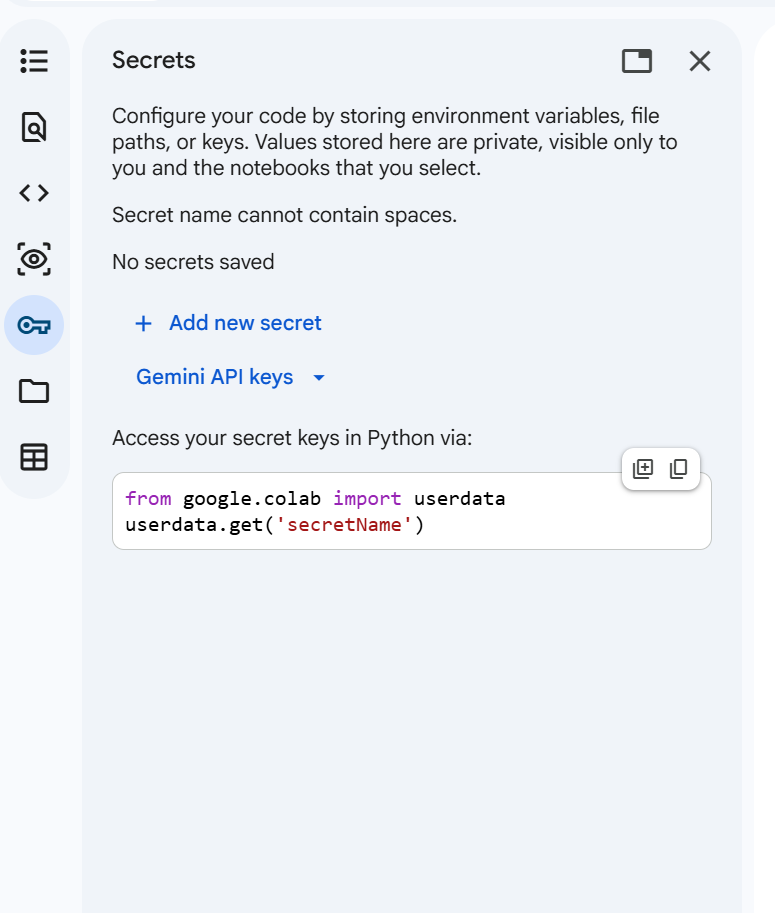

2. Then, click **+ Add new secret**. In the **Name** field, enter a name to identify the GitHub Personal Access Token, for example, **Gittoken**. In the **Value** field, paste the token. Once done, close the **Secrets** window. We will access this token programmatically later.

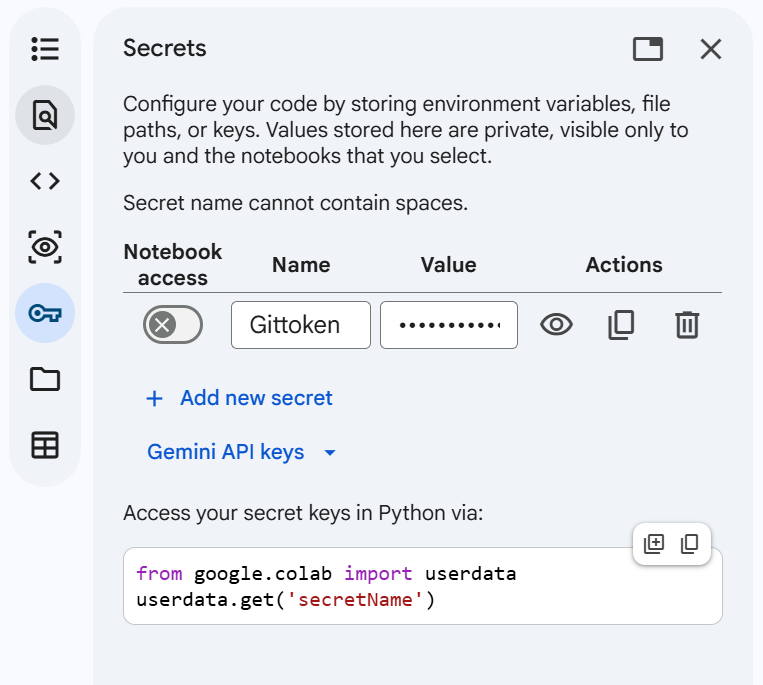

In [132]:
# Your GitHub Personal Access Token

from google.colab import userdata
GITHUB_TOKEN = userdata.get('___')  # Replace with the secret name. For example, Gittoken

# After executing this code, you may be prompted to grant access. Click **Grant Access** to continue.

In [133]:
# Name for the new repository
REPO_NAME = "superkart-sales-prediction"  # Change this if you want a different name

# Authenticate with GitHub
from github import Github

g = Github(GITHUB_TOKEN)
user = g.get_user()
print(f"Authenticated as: {user.login}")

# Create the repository
repo = user.create_repo(
    REPO_NAME,
    description="SuperKart Sales Prediction - Flask API Backend + Streamlit Frontend (Dockerized)",  # Change this if you want a different description
    private=False,
    auto_init=True  # Creates an initial README so the repo is not empty
)

print(f"Repository created successfully: {repo.html_url}")

# Dictionary mapping repo file paths to local file paths
# Backend files go under backend/ and frontend files go under frontend/
files_to_push = {
    "backend/app.py": "backend_files/app.py",
    "backend/requirements.txt": "backend_files/requirements.txt",
    "backend/Dockerfile": "backend_files/Dockerfile",
    "backend/superkart_model.joblib": "backend_files/superkart_model.joblib",
    "frontend/app.py": "frontend_files/app.py",
    "frontend/requirements.txt": "frontend_files/requirements.txt",
    "frontend/Dockerfile": "frontend_files/Dockerfile",
}

for repo_path, local_path in files_to_push.items():
    # Read the file content as bytes
    with open(local_path, "rb") as f:
        content = f.read()

    # Upload the file to the repo on the main branch
    repo.create_file(
        path=repo_path,
        message=f"Add {repo_path}",
        content=content,
        branch="main"
    )
    print(f"Uploaded: {repo_path}")

print(f"\nAll files pushed successfully to: {repo.html_url}")

Authenticated as: gllearn
Repository created successfully: https://github.com/gllearn/superkart-sales-prediction
Uploaded: backend/app.py
Uploaded: backend/requirements.txt
Uploaded: backend/Dockerfile
Uploaded: backend/superkart_model.joblib
Uploaded: frontend/app.py
Uploaded: frontend/requirements.txt
Uploaded: frontend/Dockerfile

All files pushed successfully to: https://github.com/gllearn/superkart-sales-prediction


Once the files have been successfully pushed to GitHub, the previous code cell will display an output similar to the following:

```text
All files pushed successfully to: https://github.com/gllearn/superkart-sales-prediction
```

**After the files have been pushed successfully, deploy the app using GitHub Codespaces.**

# **Inferencing using Flask API**

As the ***frontend and backend are decoupled***, we can ***access the backend directly for predictions***.
- The decoupling ensures seamless interaction with the deployed model while leveraging the API for scalable inference.

Let's see how to interact with the deployed Flask API running inside a GitHub Codespace to perform **online** and **batch inference** from this Colab notebook.

We will:
1. Send API requests for both online and batch inference.
2. Process and check the model predictions.

**Before running the cells below**, make sure:
- Your Codespace is running with both containers up
- Port 7860 has been set to **Public** in the Codespace Ports tab
- You have copied the forwarded URL for port 7860
- You have also referred the document titled **`Guided Hands-on - Containerized Model Deployment using GitHub Codespaces`** provided

In [ ]:
import json  # To handle JSON formatting for API requests and responses
import requests  # To send HTTP requests to the deployed Flask API

import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations

In [134]:
model_root_url = "https://ubiquitous-succotash-jrrpw7vvvvqjhj5gj-7860.app.github.dev/"  # Replace with your Codespace forwarded URL for port 7860

Replace the URL above with the actual forwarded URL from your Codespace's Ports tab. It will look something like `https://organic-space-abcd1234-7860.app.github.dev`. Make sure there is no trailing slash at the end.

This URL is a tunnel that Codespaces creates to route external HTTP requests into your Codespace and to the Flask container running on port 7860.

In [135]:
model_url = model_root_url + "/v1/predict"  # Endpoint for online (single) inference

Since our model predictions are provided by the following endpoint we created using Flask, we need to invoke the same to make prediction.

> ```@superkart_api.post('/v1/predict')```

In [136]:
model_batch_url = model_root_url + "/v1/predictbatch"  # Endpoint for batch inference

> ```@superkart_api.post('/v1/predictbatch')```

## Online

**Online Inference:** Sending a single request to the API and receiving an immediate response. This is useful for real-time applications like recommendation systems and fraud detection.  
* This data is sent as a JSON payload in a POST request to the model endpoint.

* The model processes the input features and returns a prediction.

In [137]:
payload = {
  "Product_Weight": 12.66,
  "Product_Sugar_Content": "Low Sugar",
  "Product_Allocated_Area": 0.027,
  "Product_MRP": 117.08,
  "Store_Size": "Medium",
  "Store_Location_City_Type": "Tier 2",
  "Store_Type": "Supermarket Type2",
  "Product_Id_char": "FD",
  "Store_Age_Years": 16,
  "Product_Type_Category": "Non Perishables"
}

In [138]:
# Sending a POST request to the model endpoint with the test payload
response = requests.post(model_url, json=payload)

In [139]:
response

<Response [200]>

`<Response [200]>` indicates that the HTTP request was successful.  

- `Response` is the object returned by `requests.post()`.  
- `[200]` is the HTTP status code, meaning **OK** (the request was processed successfully).  

In [140]:
print(response.json())

{'Sales': 3299.09619140625}


`response.json()` is used to parse the response body as JSON.  
- If the API returns data in JSON format, `.json()` converts it into a Python dictionary.  
- This allows easy access to specific values using keys.  

## Batch

**Batch Inference:** Sending multiple inputs in a single request, allowing efficient processing of large datasets. This is ideal for analyzing historical data at scale.

In [149]:
batch_dataset = pd.read_csv("Batch_Data_SuperKart.csv")

**Note**: The batch CSV file must contain all the feature columns expected by the model: `Product_Weight`, `Product_Sugar_Content`, `Product_Allocated_Area`, `Product_MRP`, `Store_Size`, `Store_Location_City_Type`, `Store_Type`, `Product_Id_char`, `Store_Age_Years`, `Product_Type_Category`.

In [150]:
# Prepare batch input for API request
batch_input = {
    'file': batch_dataset.to_csv(header=True, index=False).encode('utf-8')
}

This code prepares the product data as a **file-like object** to send in an API request (in the `files` parameter of `requests.post`).

- `batch_dataset`: This is a Pandas DataFrame containing the product data loaded from a CSV file.

- `.to_csv(header=True, index=False)`: Converts the DataFrame into a CSV **string**, keeping the column headers (`header=True`) but **excluding the index** (`index=False`).

- `.encode('utf-8')`: Encodes the CSV string into **bytes** (UTF-8 format), which is necessary for sending it over an HTTP request.

- `'file': ...`: Wraps the encoded CSV data in a dictionary with the key `'file'`, which is expected by the Flask backend.

In [151]:
# Send request to the model API for batch predictions
response = requests.post(
    model_batch_url,  # Model endpoint URL
    files=batch_input
)

This line sends a **POST request** to the deployed model API to perform **batch sales prediction**.

- `requests.post(...)`: This uses the `requests` library to make a **POST** request to a web server (in this case, our API endpoint for batch predictions).

- `model_batch_url`: This is the URL endpoint where the batch prediction API is hosted. It should look like this:\
  `"https://<your-codespace-name>-7860.app.github.dev/v1/predictbatch"`

- `files=batch_input`: This sends the batch data file (e.g., a CSV) as part of the request using the `files` parameter.

- `response`: This is the result of the API call and contains the response from the server, including predicted sales values.

In [152]:
response

<Response [200]>

In [153]:
# Extract predictions from API response
response.text

'{"0":2685.43,"1":3253.11,"2":4080.78,"3":2319.96,"4":3402.6,"5":4284.05,"6":2005.04,"7":3087.47,"8":4864.13,"9":1967.89}\n'

As we can see, we receive a JSON where each key represents a row index, and the value represents the model's predicted sales for that product.

# **Actionable Insights and Business Recommendations**

- We can use this forecasting model to predict the total sales that will be done by SuperKart in the next quarter.

- The model explains around 90% of the variation in the data and can predict within ~6.5% of the actual sales of the product.

- **OUT004** - OUT004, which is of Supermarket Type2, located in a Tier 2 city and having store size as medium, is performing well. SuperKart can look to increase the size of this store from medium to high. They can also look to set up stores in this type of city having comparable socio-economic conditions in order to expand their business and reach.

- **OUT002** - OUT002, being a food mart in a Tier 3 city and having small store size, is also performing well. SuperKart can look to upgrade its size or target similar cities for business expansion.

- **OUT001** - OUT001 which is a store of Supermarket Type 1, located in a Tier 2 city and having store size as high is not performing upto the mark. SuperKart can look to look build new marketing strategies (maybe give attractive discounts and offers) in this store in order to attract more customers.

- **OUT003** - Similar approach can be taken to increase the business of OUT003 which is a Departmental store in a Tier 1 city and having store size as medium. It is the premium store of the company where most of the costly goods are sold, so the correct set of audience should be targetted.

- Daily needs like fruits and vegetables and snack foods are the biggest contributors to the revenue across all the stores. So SuperKart should look to maintain the inventory of these products properly and ensure that these products never face a shortage.

**Additional information that can be collected to gain better insights -**

- Customers' details like age and gender can be incorporated in this model so that the company gets to know their target audience well and can build their sales strategies according to that.

- The company should also keep a watch for the number of festive occasions present in a quarter so that they can strategize their inventory accordingly.

<font size=6 color='blue'>Power Ahead</font>
___